### Ce notebook python présente divers systèmes différentiels pour modéliser la population des neutrophiles, des Momac et des SL-TRMacrophages.

## ✅ Vérification de l'environnement Python

Cette cellule vérifie que l'environnement virtuel `.venv` est correctement chargé avec tous les packages nécessaires.

In [1]:
import sys
import platform

# Afficher l'interpréteur Python utilisé
print("=" * 70)
print("ENVIRONNEMENT PYTHON")
print("=" * 70)
print(f"Interpréteur : {sys.executable}")
print(f"Version Python : {platform.python_version()}")
print(f"Plateforme : {platform.platform()}")
print()

# Vérifier les packages installés
print("=" * 70)
print("PACKAGES INSTALLÉS")
print("=" * 70)

packages_to_check = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sympy', 'sympy'),
    ('skimage', 'scikit-image'),
    ('ipywidgets', 'ipywidgets')
]

all_ok = True
for module_name, package_name in packages_to_check:
    try:
        mod = __import__(module_name)
        version = getattr(mod, '__version__', 'N/A')
        print(f"✓ {package_name:20s} version {version}")
    except ImportError as e:
        print(f"✗ {package_name:20s} NON INSTALLÉ")
        all_ok = False

print("=" * 70)
if all_ok:
    print("✅ Tous les packages sont correctement installés!")
else:
    print("⚠️  Certains packages sont manquants. Veuillez les installer.")
print("=" * 70)

ENVIRONNEMENT PYTHON
Interpréteur : /home/pascal/imagcloud/IMMUN4CURE/brain-storming/immunomath/.venv/bin/python
Version Python : 3.12.3
Plateforme : Linux-6.8.0-139-generic-x86_64-with-glibc2.39

PACKAGES INSTALLÉS
✓ np                   version 2.3.5
✓ scipy                version 1.16.3
✓ matplotlib           version 3.10.7
✓ sympy                version 1.14.0
✓ scikit-image         version 0.25.2
✓ ipywidgets           version 8.1.8
✅ Tous les packages sont correctement installés!


# Nouveau modèle (réunion du 11/07)

Ce notebook est centré sur le nouveau modèle proposé lors de la réunion du 11/07, avec Florence, Gabriel et Olivier

### <span style="color:red">nouveau modèle</span> suggéré par Olivier et Oana
$S(t)$ variable qui modélise l'état inflammatoire résultant de l'injection du signal immun et de l'activation des chimiokines dans les macrophages lining et les fibroblastes. 

L'état inflammatoire  $S(t)$ est renforcé par les neutrophiles N et inhibés par les  macrophages SL-TRM T.

L'inflammation fait croître davantage les neutrophiles (facteur $\alpha$), elle fait croître les momac (facteur $\beta$) et elle fait décroître les SL-TRM (facteur $\gamma$)

**On ne suit plus la population de fibroblastes, mais plutôt la population de neutrophiles qui sont appelés par les chimiokines inflammatoires.**

N(t) : population de <span style="color:red">neutrophiles</span>

M(t) : population de Momac

T(t) : population de macrophages SL-TRM

$$ \begin{aligned}
\frac{dS}{dt} &=& \color{red}{(a\, N - b\,T)} & \, S & \\
\frac{dN}{dt} &=& \alpha \, S\,N &-\delta_N\,N\cdot (N-1)& \\
\frac{dM}{dt} &=&  \beta\,\color{red} {\, S} &&-\delta_M\, M\cdot (M-1) \\
\frac{dT}{dt} &=&-\gamma S\, T & &+\delta_M\,M\cdot (1-T)
\end{aligned}
$$

```mermaid
flowchart LR
    subgraph "Modèle 4 compartiments"
        S["Signal immun inflammatoire"]
        N["Neutrophiles"]
        M["Momac (Monocytes/Macrophages)"]
        T["SL-TRM Macrophages"]
    end

    N -- "renforce (a)" --> S
    T -- "inhibe (b)" --> S
    S -- "croissance (α)" --> N
    S -- "croissance (β)" --> M
    S -- "décroissance (γ)" --> T
    N -- "destruction (δ_N)" --> N
    M -- "destruction (δ_M)" --> M
    M -- "conversion (δ_M)" --> T


![Schéma du modèle](/home/pascal/imagcloud/IMMUN4CURE/brain-storming/schema_mermaid.png)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from ipywidgets import interact, fixed

## 2. Définir le système différentiel du nouveau modèle

La fonction `system_adim_oliv` implémente les équations différentielles du modèle adimensionné avec neutrophiles, Momac, SL-TRM et signal inflammatoire, selon la proposition d'Olivier et Oana.

In [3]:
def system_adim_oliv(t, y, alpha, beta, gamma, delta_N, delta_M, a, b):
    """
    y : vecteur (S N M T) 
    S : signal inflammatoire adimensionné
    N : Neutrophiles adimensionnés
    M : Monocytes Macrophages  adimensionnés
    T : SL-TRM Macrophages adimensionnés

    la valeur d'équilibre physiologique des neutrophiles est 1
    la valeur d'équilibre physiologique des Momac est 1
    la valeur d'équilibre physiologique des SL-TRM est 1
    alpha <1 est le taux de croissance des neutrophiles causé par l'inflammation
    beta  est le taux de croissance des Momac causé par l'inflammation
    gamma est le taux de destruction des SL-TRM causé par l'inflammation 
    delta_N est le taux de destruction des neutrophiles
    delta_M est le taux de conversion  Momac -> SL-TRM  
    """

    S, N, M, T = y

    dSdt =  (a* N - b* T)*S
    dNdt = alpha * S*N - delta_N * N * (N-1)
    dMdt = beta *S - delta_M * M*(M-1)
    dTdt = -gamma * S * T + delta_M *M *(1-T)

    return [dSdt, dNdt, dMdt, dTdt]

La fonction `system_adim_andrea` implémente les équations différentielles du modèle adimensionné avec neutrophiles, Momac, SL-TRM et signal inflammatoire, selon la proposition d'Olivier et Oana, *en preant un paramètre supplémentaire $\delta_T \neq \delta_M$ dans la dernière équation.*

In [4]:
def system_adim_andrea(t, y, alpha, beta, gamma, delta_N, delta_M, delta_T, a, b):
    """
    y : vecteur (S N M T) 
    S : signal inflammatoire adimensionné
    N : Neutrophiles adimensionnés
    M : Monocytes Macrophages  adimensionnés
    T : SL-TRM Macrophages adimensionnés

    la valeur d'équilibre physiologique des neutrophiles est 1
    la valeur d'équilibre physiologique des Momac est 1
    la valeur d'équilibre physiologique des SL-TRM est 1
    alpha <1 est le taux de croissance des neutrophiles causé par l'inflammation
    beta  est le taux de croissance des Momac causé par l'inflammation
    gamma est le taux de destruction des SL-TRM causé par l'inflammation 
    delta_N est le taux de destruction des neutrophiles
    delta_M est le taux de conversion  Momac -> SL-TRM  
    """

    S, N, M, T = y

    dSdt =  (a* N - b* T)*S
    dNdt = alpha * S*N - delta_N * N * (N-1)
    dMdt = beta *S - delta_M * M*(M-1)
    dTdt = -gamma * S * T + delta_T *M *(1-T)

    return [dSdt, dNdt, dMdt, dTdt]

La fonction  `system_adim_degrad` inclut un terme de degradation pour le signal inflammatoire. 
$$ \begin{aligned}
\frac{dS}{dt} &=& \color{red}{(a\, N - b\,T - c)} & \, S & \\
\frac{dN}{dt} &=& \alpha \, S\,N &-\delta_N\,N\cdot (N-1)& \\
\frac{dM}{dt} &=&  \beta\,\color{red} {\, S} &&-\delta_M\, M\cdot (M-1) \\
\frac{dT}{dt} &=&-\gamma S\, T & &+\delta_M\,M\cdot (1-T)
\end{aligned}
$$
Typiquement si $S' = -c S$ on aurait $S(t) = S(0) \exp(-ct)$ donc $$c= \frac{\ln 2} {t_{1/2}}\approx \frac{0.7} {t_{1/2}}.$$
Ainsi pour $t_{1/2} = 7$ jours, $c\approx 0.1.$

In [5]:
def system_adim_degrad(t, y, alpha, beta, gamma, delta_N, delta_M, a, b, c):
    """
    y : vecteur (S N M T) 
    S : signal inflammatoire adimensionné
    N : Neutrophiles adimensionnés
    M : Monocytes Macrophages  adimensionnés
    T : SL-TRM Macrophages adimensionnés

    la valeur d'équilibre physiologique des neutrophiles est 1
    la valeur d'équilibre physiologique des Momac est 1
    la valeur d'équilibre physiologique des SL-TRM est 1
    alpha <1 est le taux de croissance des neutrophiles causé par l'inflammation
    beta  est le taux de croissance des Momac causé par l'inflammation
    gamma est le taux de destruction des SL-TRM causé par l'inflammation 
    delta_N est le taux de destruction des neutrophiles
    delta_M est le taux de conversion  Momac -> SL-TRM 
    c est le taux de dégradation du signal inflammatoire
    typiquement c = Ln(2)/t1/2, avec t1/2 la demi-vie du signal inflammatoire
    ce qui donne c = 0.693/1 = 0.693 pour une demi-vie de 24h
    a est le taux de production du signal inflammatoire par les neutrophiles
    b est le taux de destruction du signal inflammatoire par les SL-TRM
    """

    S, N, M, T = y

    dSdt =  (a* N - b* T)*S - c*S
    dNdt = alpha * S*N - delta_N * N * (N-1)
    dMdt = beta *S - delta_M * M*(M-1)
    dTdt = -gamma * S * T + delta_M *M *(1-T)

    return [dSdt, dNdt, dMdt, dTdt]

## 3. Définir la fonction de simulation

La fonction `inflam_adim_oliv` résout le système différentiel et trace les résultats pour visualiser l'évolution des différentes populations et du signal inflammatoire.

In [6]:
def inflam_adim_oliv(y0, alpha, beta, gamma, delta_N, delta_M, a, b, duree):

    # Résolution des équations différentielles du modèle de la réponse immunitaire
    # le système est raide, on utilise la méthode BDF
    sol = solve_ivp(system_adim_oliv, [0, duree], y0, 'Radau',t_eval=np.arange(0,duree,duree/1000), dense_output=False,
                    args=(alpha, beta, gamma, delta_N, delta_M, a, b))
    S,N,M,T = sol.y
    t=sol.t
    # Traçage des résultats
    plt.figure(figsize=(12, 8))

    plt.subplot(221)
    plt.plot(t, S, 'b', label='inflammation')
    plt.ylabel('inflammation')
    plt.title('inflammatory signal')

    plt.subplot(222)
    plt.plot(t, N, 'r', label='Neutrophiles')
    plt.ylabel('Neutrophiles')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(N)
    plt.ylim(bottom=0, top=ymax)
    plt.title('neutrophiles')

    plt.subplot(223)
    plt.plot(t,M, 'g')
    plt.xlabel('time [d] ')
    plt.ylabel('Monocytes Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(M)
    plt.ylim(bottom=0, top=ymax)
    plt.title('monocytes macrophages')

    plt.subplot(224)
    plt.plot(t,T, 'm')
    plt.xlabel('time [d] ')
    plt.ylabel('SL-TRM Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(T)
    plt.ylim(bottom=0, top=ymax )
    plt.title('macrophages SL-TRM')

    #plt.subplot(325)
    #plt.plot(M,T, 'm')
    #plt.xlabel('Momac')
    #plt.ylabel('SL-TRM Macrophages')
    #plt.ticklabel_format(style='plain', axis='y')
    #ymax = 1.5 * np.max(T)
    #plt.ylim(bottom=0, top=ymax)
    #plt.figtext(0.3, 0.01, 'Plan de phase entre Momac et SL-TRM ', ha='center', fontsize=12)

    #plt.subplot(326)
    #plt.plot(S,T, 'm')
    #plt.xlabel('signal inflammatoire')
    #plt.ylabel('SL-TRM Macrophages')
    #plt.ticklabel_format(style='plain', axis='y')
    #ymax = 1.5 * np.max(T)
    #plt.ylim(bottom=0, top=ymax)
    #plt.figtext(0.7, 0.01, 'Plan de phase entre inflammation et SL-TRM ', ha='center', fontsize=12)

    print('valeurs finales:',f"Signal={S[-1]:.3f}, Neutrophiles={N[-1]:.3f}, Momac={M[-1]:.3f}, SL-TRM={T[-1]:.3f}")
    plt.show()
    return

In [7]:
def inflam_adim_andrea(y0, alpha, beta, gamma, delta_N, delta_M, delta_T, a, b, duree):

    # Résolution des équations différentielles du modèle de la réponse immunitaire
    # le système est raide, on utilise la méthode BDF
    sol = solve_ivp(system_adim_andrea, [0, duree], y0, 'Radau',t_eval=np.arange(0,duree,duree/1000), dense_output=False,
                    args=(alpha, beta, gamma, delta_N, delta_M, delta_T, a, b))
    S,N,M,T = sol.y
    t=sol.t
    # Traçage des résultats
    plt.figure(figsize=(12, 8))

    plt.subplot(221)
    plt.plot(t, S, 'b', label='inflammation')
    plt.ylabel('inflammation')
    plt.title('inflammatory signal')

    plt.subplot(222)
    plt.plot(t, N, 'r', label='Neutrophiles')
    plt.ylabel('Neutrophiles')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(N)
    plt.ylim(bottom=0, top=ymax)
    plt.title('neutrophiles')

    plt.subplot(223)
    plt.plot(t,M, 'g')
    plt.xlabel('time [d] ')
    plt.ylabel('Monocytes Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(M)
    plt.ylim(bottom=0, top=ymax)
    plt.title('monocytes macrophages')

    plt.subplot(224)
    plt.plot(t,T, 'm')
    plt.xlabel('time [d] ')
    plt.ylabel('SL-TRM Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(T)
    plt.ylim(bottom=0, top=ymax )
    plt.title('macrophages SL-TRM')

    print('valeurs finales:',f"Signal={S[-1]:.3f}, Neutrophiles={N[-1]:.3f}, Momac={M[-1]:.3f}, SL-TRM={T[-1]:.3f}")
    plt.show()
    return

In [8]:
def inflam_adim_degrad(y0, alpha, beta, gamma, delta_N, delta_M, a, b, c, duree):

    # Résolution des équations différentielles du modèle de la réponse immunitaire
    # le système est raide, on utilise la méthode BDF
    sol = solve_ivp(system_adim_degrad, [0, duree], y0, 'Radau',t_eval=np.arange(0,duree,duree/1000), dense_output=False,
                    args=(alpha, beta, gamma, delta_N, delta_M, a, b, c ))
    S,N,M,T = sol.y
    t=sol.t
    # Traçage des résultats
    plt.figure(figsize=(12, 8))

    plt.subplot(221)
    plt.plot(t, S, 'b', label='inflammation')
    plt.ylabel('inflammation')
    plt.title('inflammatory signal')

    plt.subplot(222)
    plt.plot(t, N, 'r', label='Neutrophiles')
    plt.ylabel('Neutrophiles')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(N)
    plt.ylim(bottom=0, top=ymax)
    plt.title('neutrophiles')

    plt.subplot(223)
    plt.plot(t,M, 'g')
    plt.xlabel('time [d] ')
    plt.ylabel('Monocytes Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(M)
    plt.ylim(bottom=0, top=ymax)
    plt.title('monocytes macrophages')

    plt.subplot(224)
    plt.plot(t,T, 'm')
    plt.xlabel('time [d] ')
    plt.ylabel('SL-TRM Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(T)
    plt.ylim(bottom=0, top=ymax )
    plt.title('macrophages SL-TRM')

    #plt.subplot(325)
    #plt.plot(M,T, 'm')
    #plt.xlabel('Momac')
    #plt.ylabel('SL-TRM Macrophages')
    #plt.ticklabel_format(style='plain', axis='y')
    #ymax = 1.5 * np.max(T)
    #plt.ylim(bottom=0, top=ymax)
    #plt.figtext(0.3, 0.01, 'Plan de phase entre Momac et SL-TRM ', ha='center', fontsize=12)

    #plt.subplot(326)
    #plt.plot(S,T, 'm')
    #plt.xlabel('signal inflammatoire')
    #plt.ylabel('SL-TRM Macrophages')
    #plt.ticklabel_format(style='plain', axis='y')
    #ymax = 1.5 * np.max(T)
    #plt.ylim(bottom=0, top=ymax)
    #plt.figtext(0.7, 0.01, 'Plan de phase entre inflammation et SL-TRM ', ha='center', fontsize=12)

    print('valeurs finales:',f"Signal={S[-1]:.3f}, Neutrophiles={N[-1]:.3f}, Momac={M[-1]:.3f}, SL-TRM={T[-1]:.3f}")
    plt.show()
    return

## 4. Exécuter une simulation de base avec inflam_adim_oliv

On observe le comportement du modèle avec des paramètres standards.

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


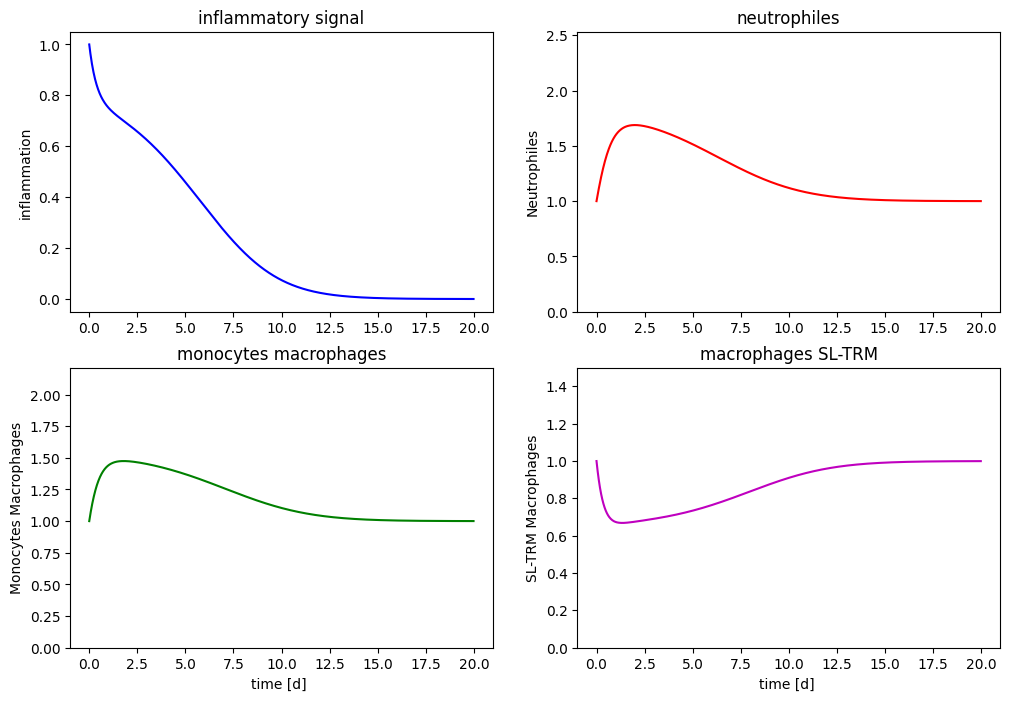

In [9]:
inflam_adim_oliv([1, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=0.35, b=1, duree=20)

Compararaison avec inflam_adim_andrea.

valeurs finales: Signal=705.770, Neutrophiles=523.806, Momac=12.220, SL-TRM=0.011


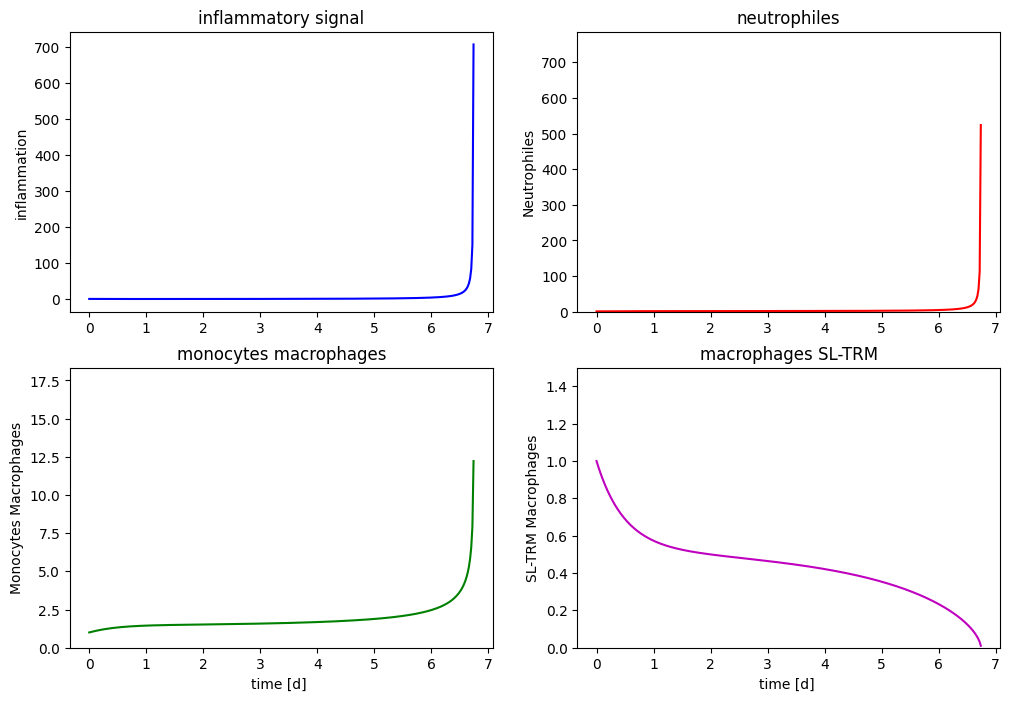

In [10]:
inflam_adim_andrea([1, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1, delta_T=0.5, a=0.35, b=1, duree=20)

valeurs finales: Signal=0.011, Neutrophiles=1.023, Momac=1.022, SL-TRM=0.932


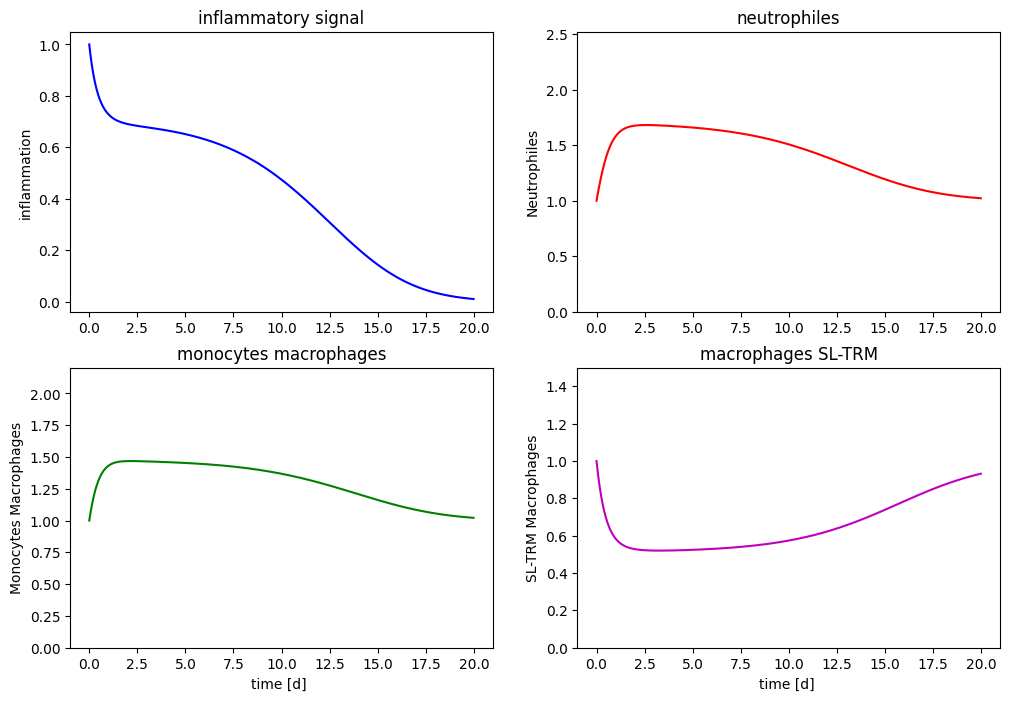

In [11]:
inflam_adim_andrea([1, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1, delta_T=0.5, a=0.30, b=1, duree=20)

## Effet de la dégradation du signal inflammatoire.

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


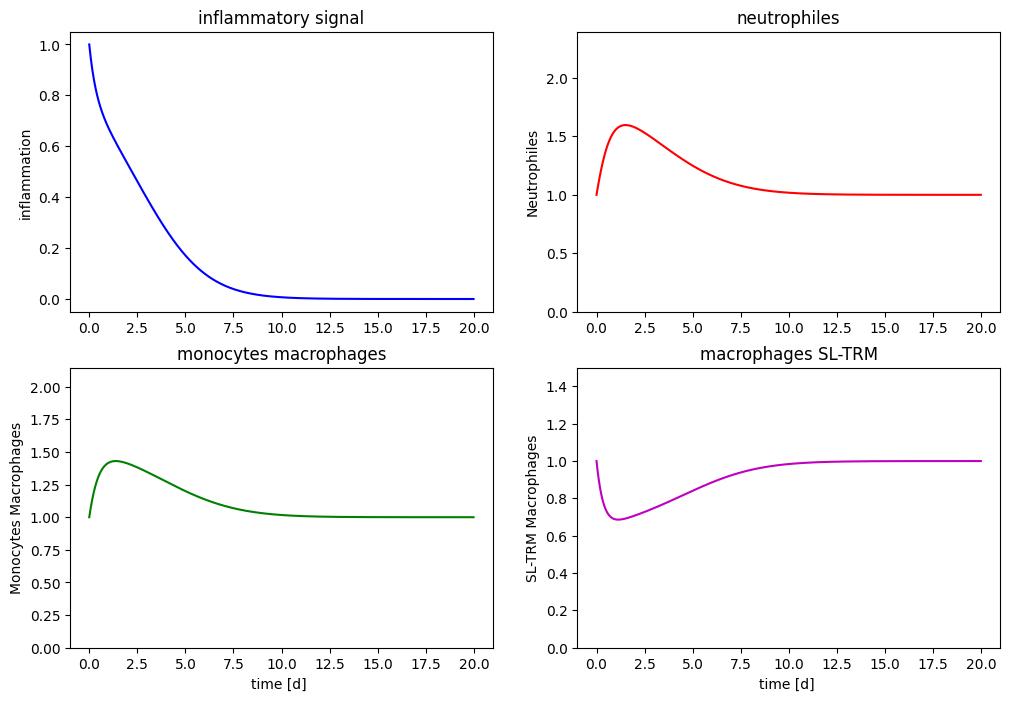

In [12]:
inflam_adim_degrad([1, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=0.35, b=1, c=0.1, duree=20)

## 5. Tester la stabilité de l’équilibre physiologique

Exemple où l’équilibre physiologique est stable (par exemple, a/b < 1).

valeurs finales: Signal=0.001, Neutrophiles=1.001, Momac=1.001, SL-TRM=0.999


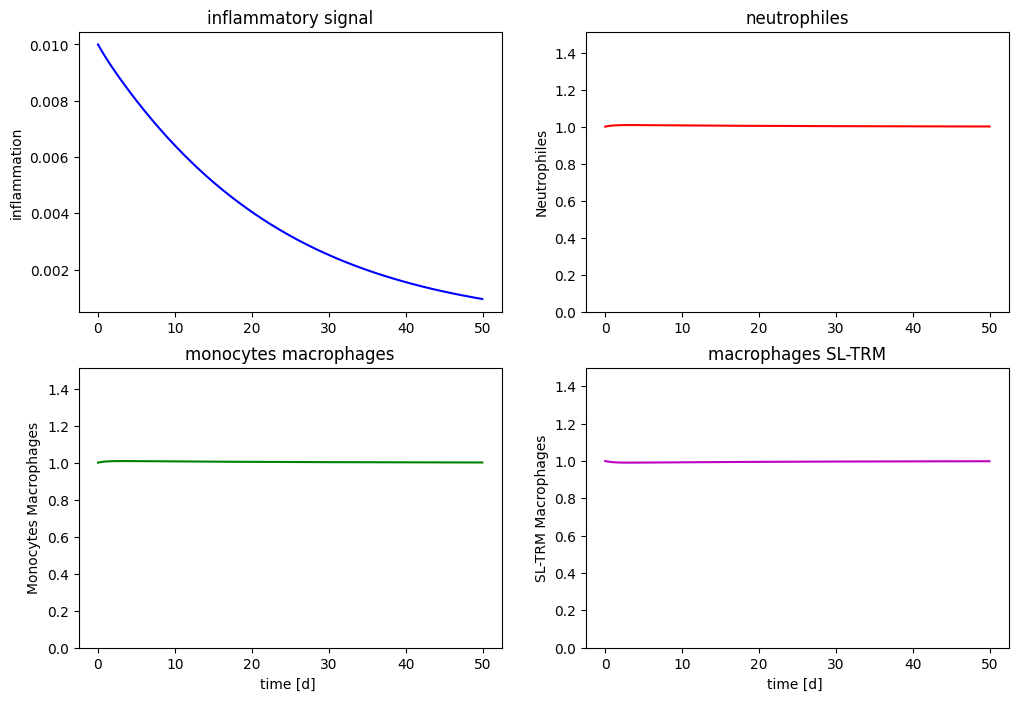

In [13]:
#l'équilibre physiologique est stable si a / b < 1
inflam_adim_oliv([0.01, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=0.35, b=0.40, duree=50)

valeurs finales: Signal=0.001, Neutrophiles=1.001, Momac=1.001, SL-TRM=0.998


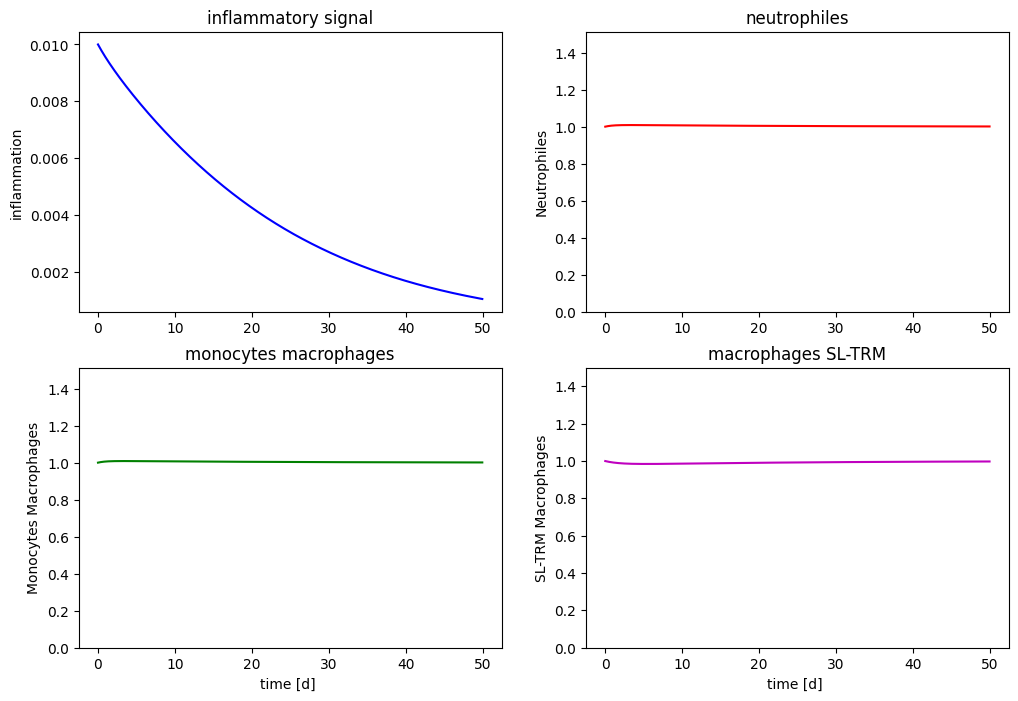

In [14]:
#l'équilibre physiologique est stable si a / b < 1
inflam_adim_andrea([0.01, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1, delta_T=0.5, a=0.35, b=0.40, duree=50)

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


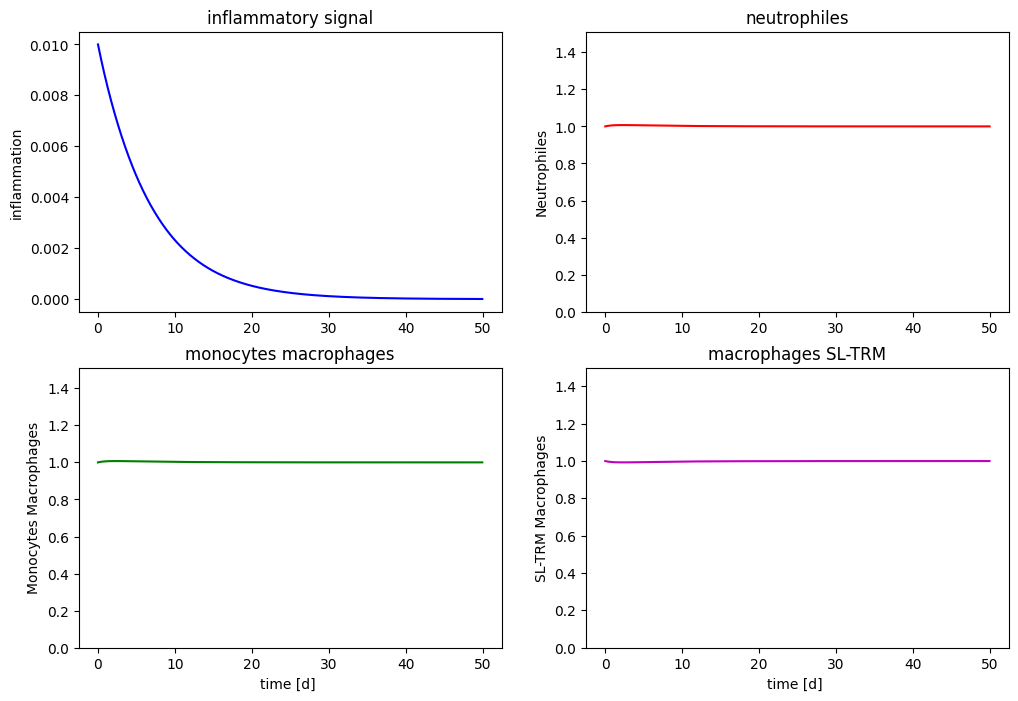

In [15]:
#l'équilibre physiologique est stable si a / b < 1
inflam_adim_degrad([0.01, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1, a=0.35, b=0.40, c=0.1, duree=50)

## 6. Tester l’instabilité de l’équilibre physiologique

Exemple où l’équilibre physiologique est instable (par exemple, a / b > seuil).

valeurs finales: Signal=0.553, Neutrophiles=1.480, Momac=1.359, SL-TRM=0.730


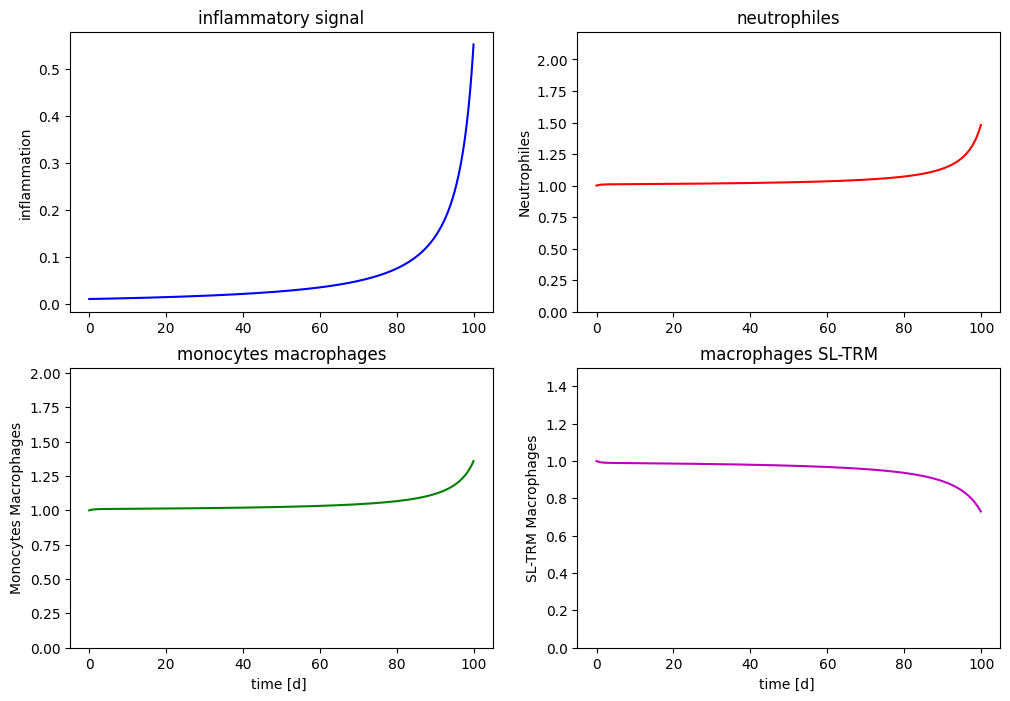

In [16]:
#l'équilibre physiologique est instable si a / b > 1
inflam_adim_oliv([0.01, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=0.31, b=0.30, duree=100)

valeurs finales: Signal=72.011, Neutrophiles=55.988, Momac=6.403, SL-TRM=0.050


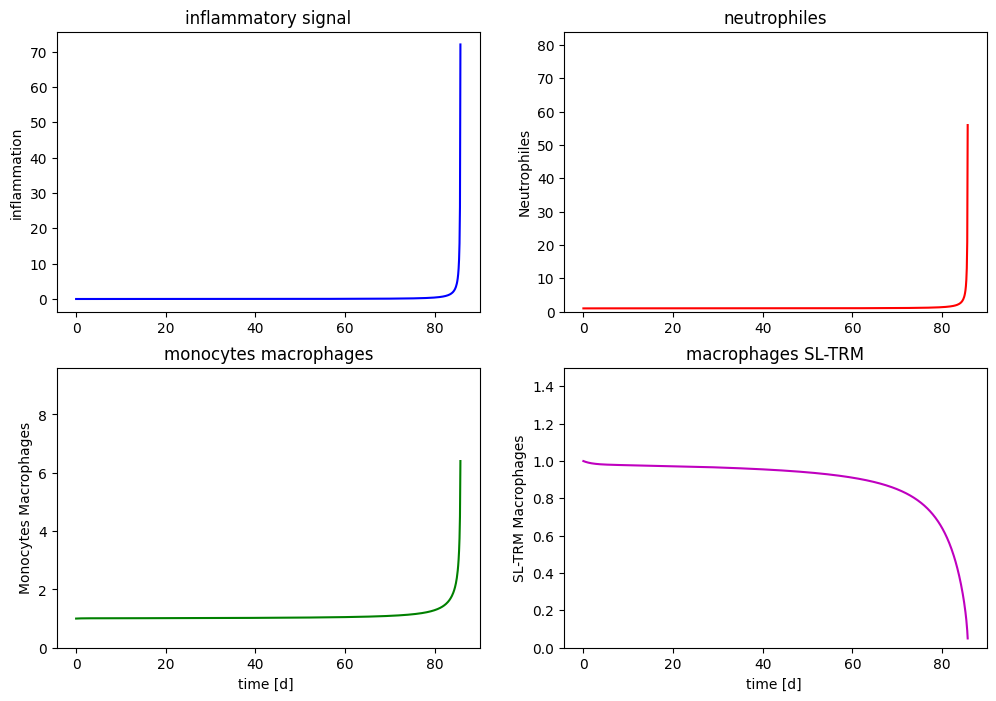

In [17]:
#l'équilibre physiologique est instable si a / b > 1
inflam_adim_andrea([0.01, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1, delta_T=0.5, a=0.31, b=0.30, duree=100)

valeurs finales: Signal=537.713, Neutrophiles=411.578, Momac=11.854, SL-TRM=0.026


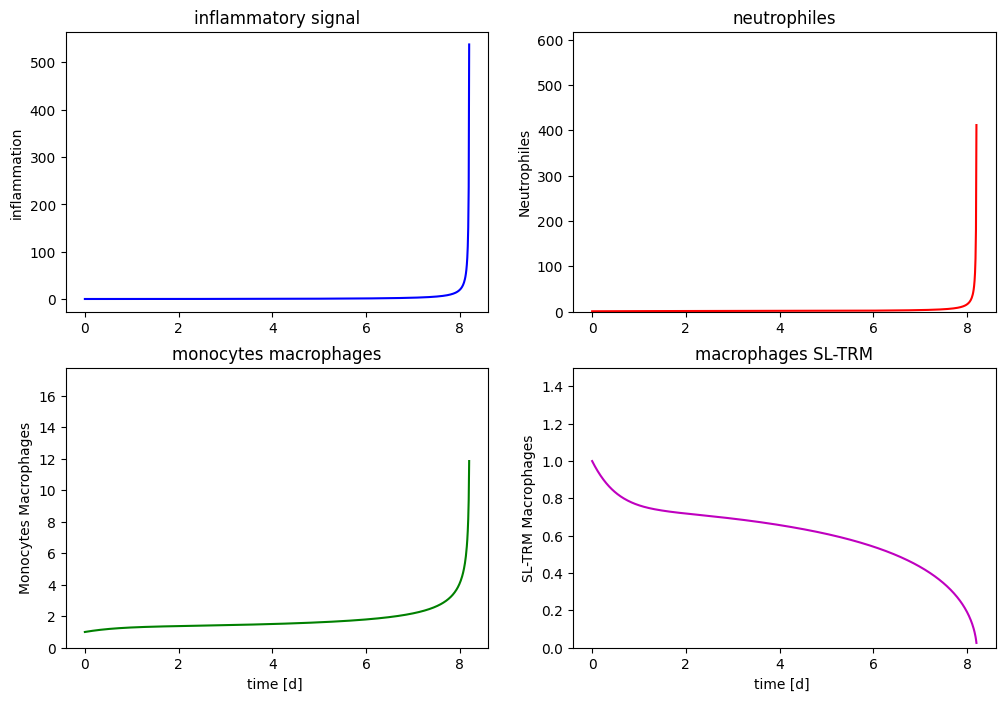

In [18]:
inflam_adim_degrad([0.5, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=0.31, b=0.30, c=0.1, duree=10)

/tmp/ipykernel_485594/3660657395.py:22: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(bottom=0, top=ymax)


valeurs finales: Signal=0.000, Neutrophiles=0.000, Momac=1.000, SL-TRM=1.000


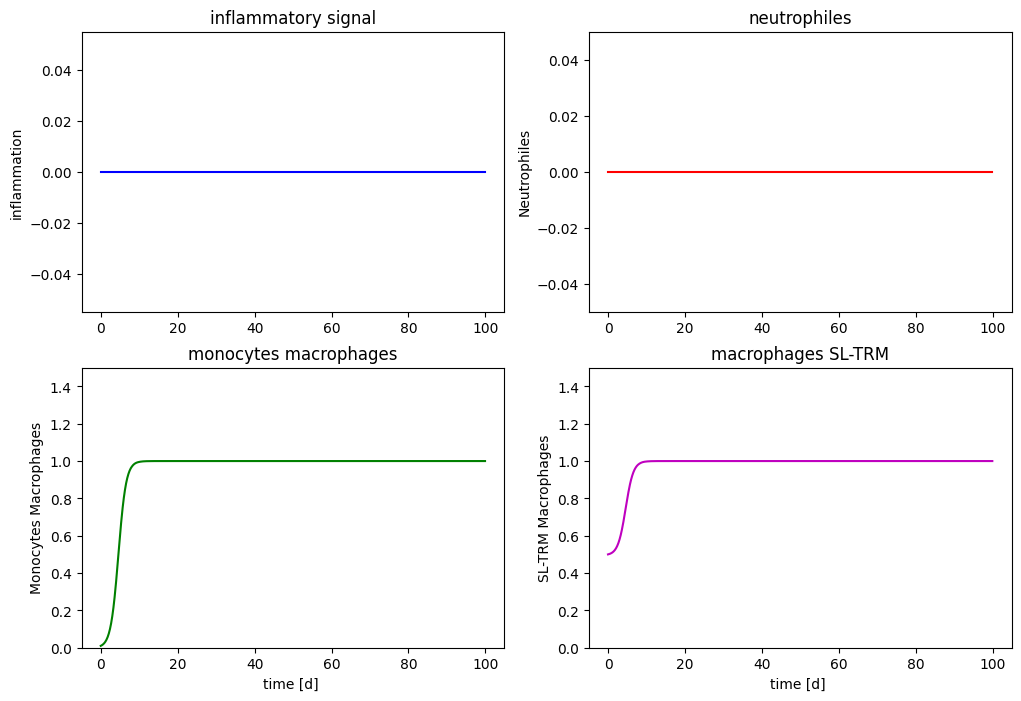

In [19]:
# test 10/10 brain storming pour instabilité des points fixes du type (0,0,0,T) avec T non nul <1
inflam_adim_oliv([0., 0, 0.01, 0.5],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=1, b=1, duree=100)


on constate que le système tend vers un autre point fixe $(S,N,M,T)=(0,0,1,1)$

/tmp/ipykernel_485594/2135449172.py:22: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(bottom=0, top=ymax)


valeurs finales: Signal=0.000, Neutrophiles=0.000, Momac=1.000, SL-TRM=1.000


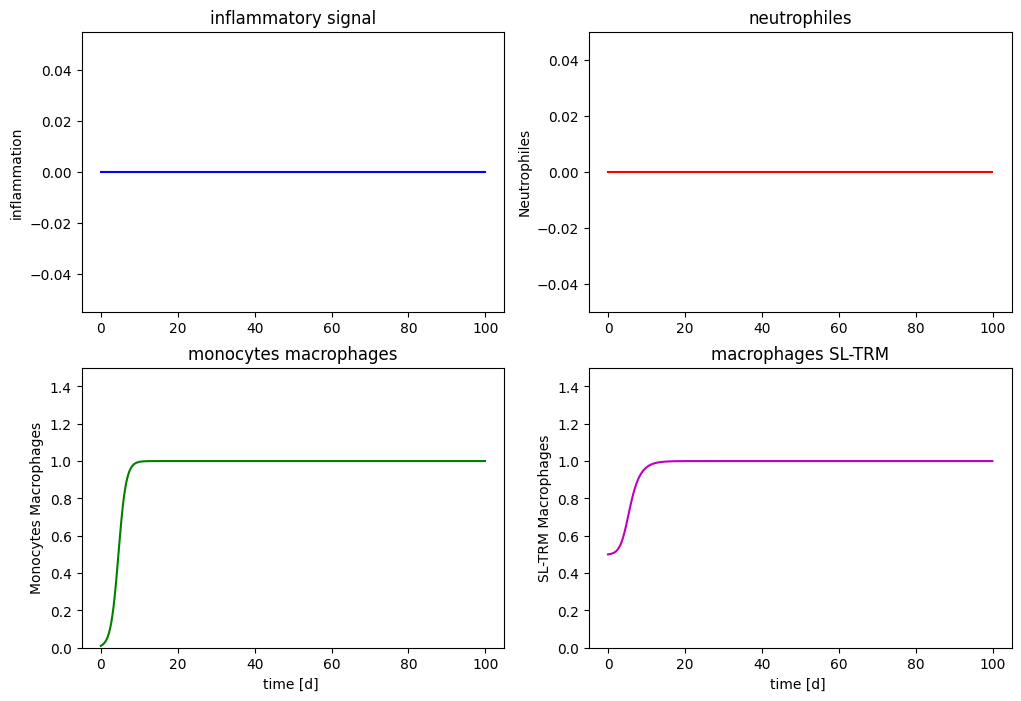

In [20]:
# test 10/10 brain storming pour instabilité des points fixes du type (0,0,0,T) avec T non nul <1
inflam_adim_andrea([0., 0, 0.01, 0.5],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1, delta_T=0.5, a=1, b=1, duree=100)


/tmp/ipykernel_485594/3660657395.py:22: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(bottom=0, top=ymax)


valeurs finales: Signal=0.000, Neutrophiles=0.000, Momac=1.000, SL-TRM=1.000


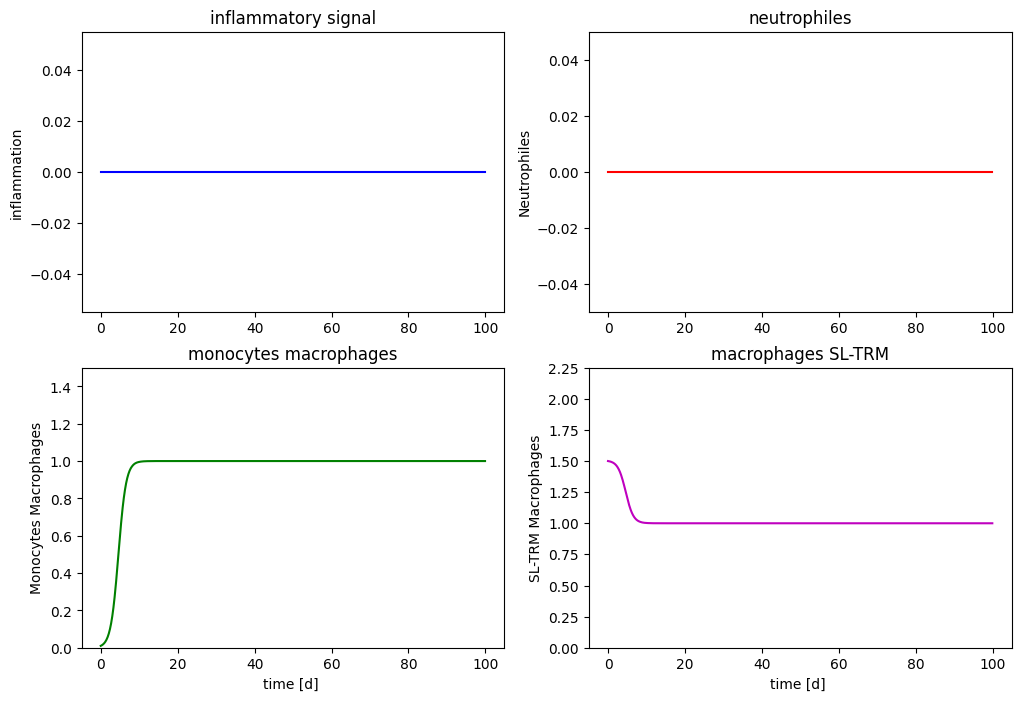

In [21]:
# test pour instabilité des points fixes du type (0,0,0,T) avec T_ini > 1
inflam_adim_oliv([0., 0, 0.01, 1.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=1, b=1, duree=100)

On constate que  le système revient encore vers un autre point fixe $(S,N,M,T)=(0,0,1,1)$

/tmp/ipykernel_485594/2135449172.py:22: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(bottom=0, top=ymax)


valeurs finales: Signal=0.000, Neutrophiles=0.000, Momac=1.000, SL-TRM=1.000


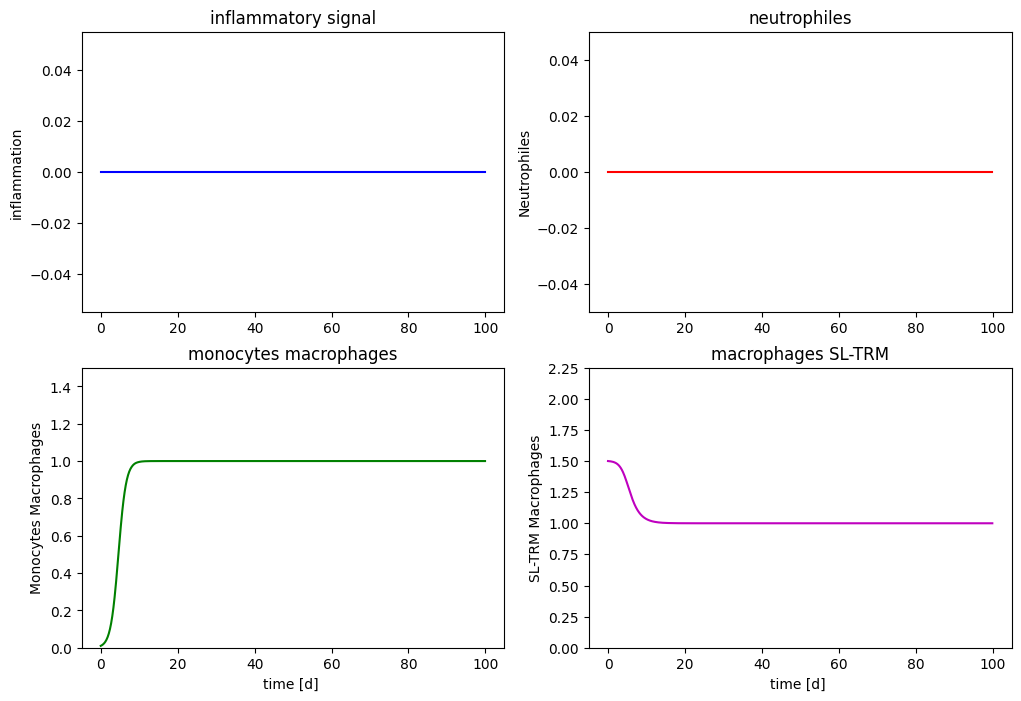

In [22]:
# test pour instabilité des points fixes du type (0,0,0,T) avec T_ini > 1
inflam_adim_andrea([0., 0, 0.01, 1.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1, delta_T=0.5, a=1, b=1, duree=100)

Il semble qu'il y ait une sous-variété invariante $\{0\}\times \{0\}\times \mathbb{R}\times\mathbb{R}$

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


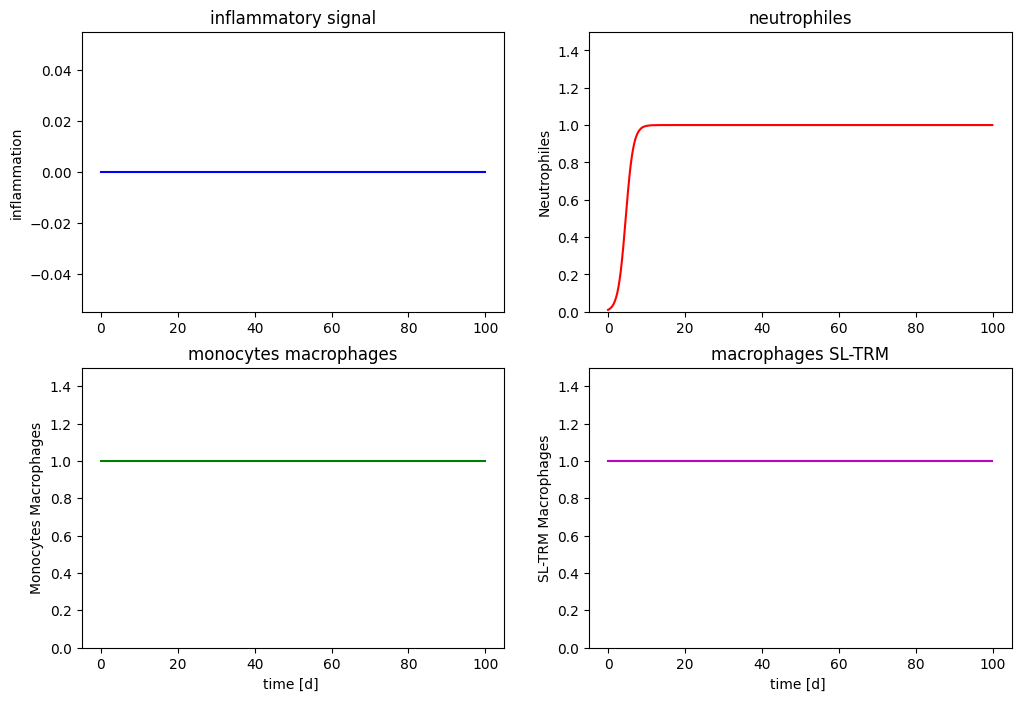

In [23]:
#test 10/10 brain storming pour instabilité des points fixes du type (0,0,1,1)
inflam_adim_oliv([0., 0.01, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=1, b=1, duree=100)


On voit que le système revient encore vers le point fixe $(S,N,M,T)=(0,1,1,1)$

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


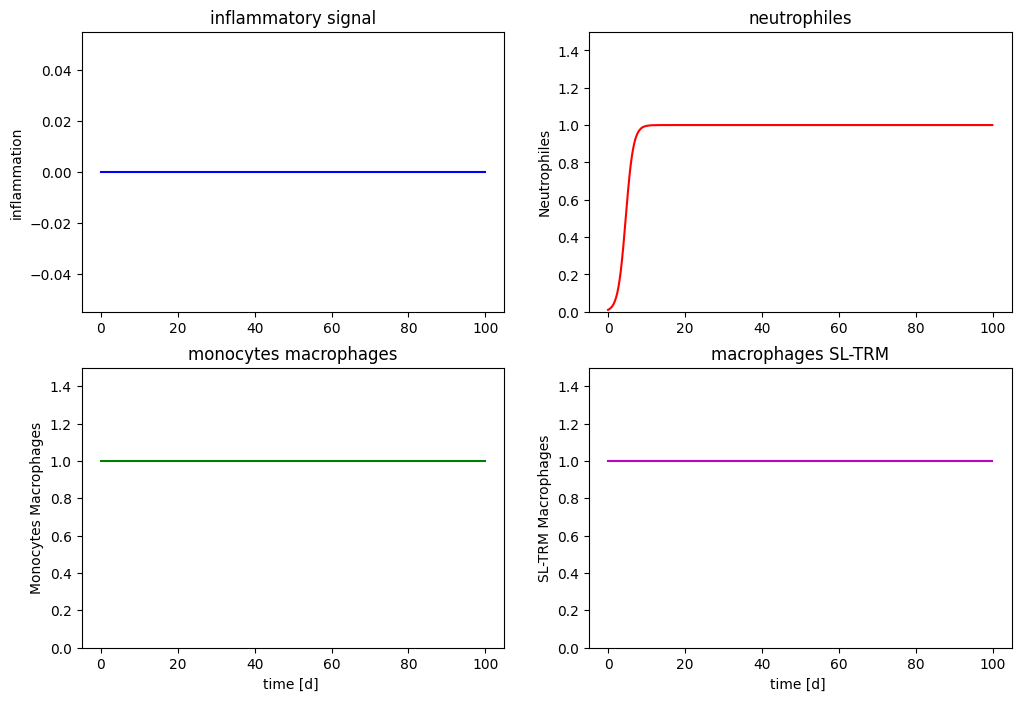

In [24]:
#test 10/10 brain storming pour instabilité des points fixes du type (0,0,1,1)
inflam_adim_andrea([0., 0.01, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1, delta_T=0.5, a=1, b=1, duree=100)


/tmp/ipykernel_485594/3660657395.py:22: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(bottom=0, top=ymax)


valeurs finales: Signal=0.000, Neutrophiles=0.000, Momac=1.000, SL-TRM=1.000


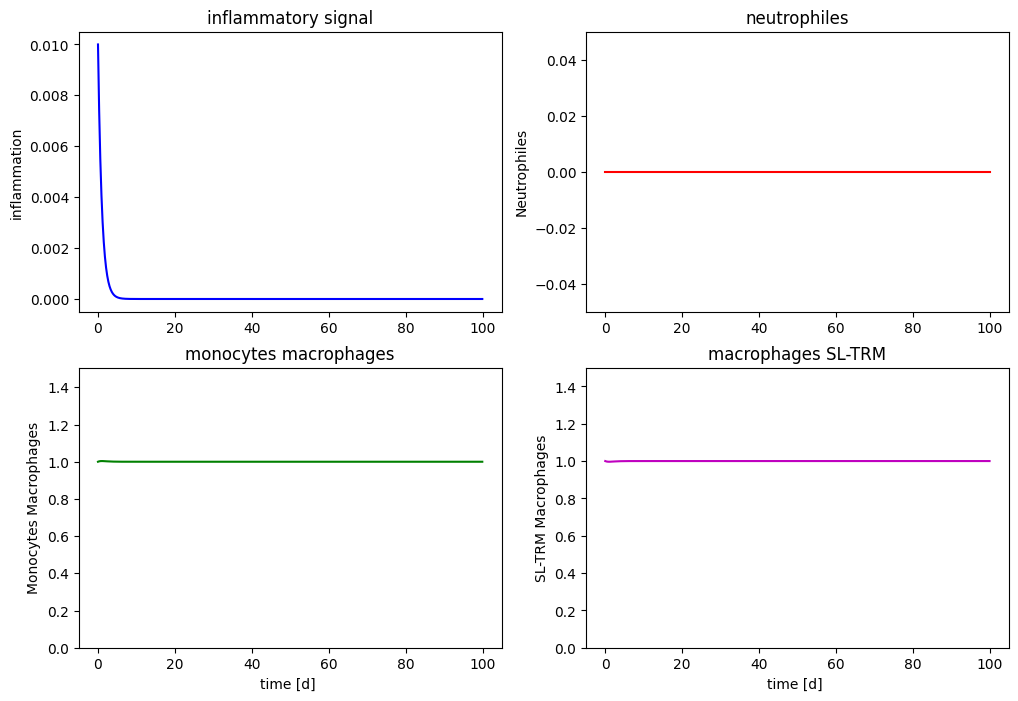

In [25]:
#test 10/10 brain storming pour instabilité des points fixes du type (0,0,1,1)
inflam_adim_oliv([0.01, 0., 1.0, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=1, b=1, duree=100)


On constate que ce point $(0,0,1,1)$ est stable pour les pertubations de $S$ et instable pour les perturbations en $N$.

/tmp/ipykernel_485594/2135449172.py:22: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(bottom=0, top=ymax)


valeurs finales: Signal=0.000, Neutrophiles=0.000, Momac=1.000, SL-TRM=1.000


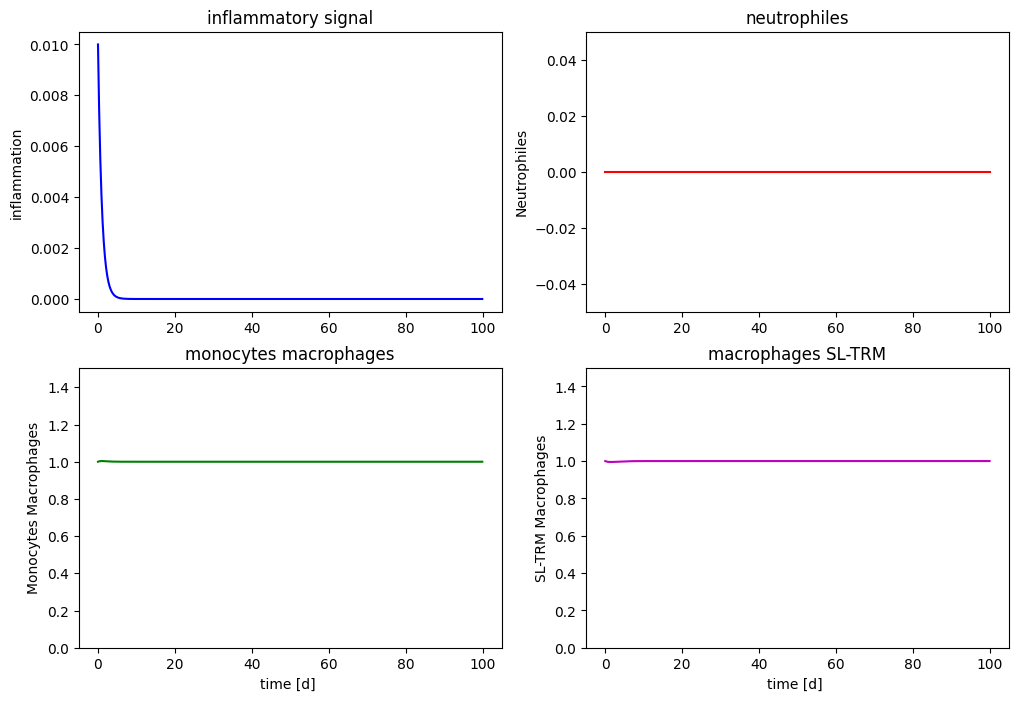

In [26]:
#test 10/10 brain storming pour instabilité des points fixes du type (0,0,1,1)
inflam_adim_andrea([0.01, 0., 1.0, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1, delta_T=0.5, a=1, b=1, duree=100)


valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


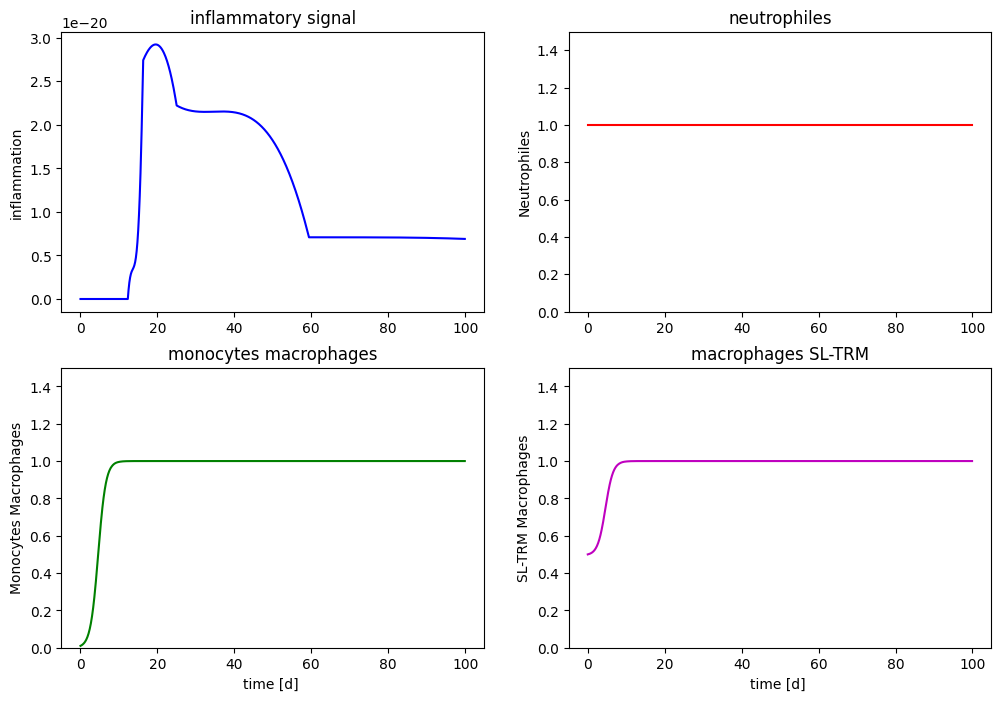

In [27]:
#test 10/10 brain storming pour instabilité des points fixes du type (0,1,0,T) avec T non nul <1
inflam_adim_oliv([0., 1, 0.01, 0.5],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=1, b=1, duree=100)


On va vers l'état physiologique. 

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


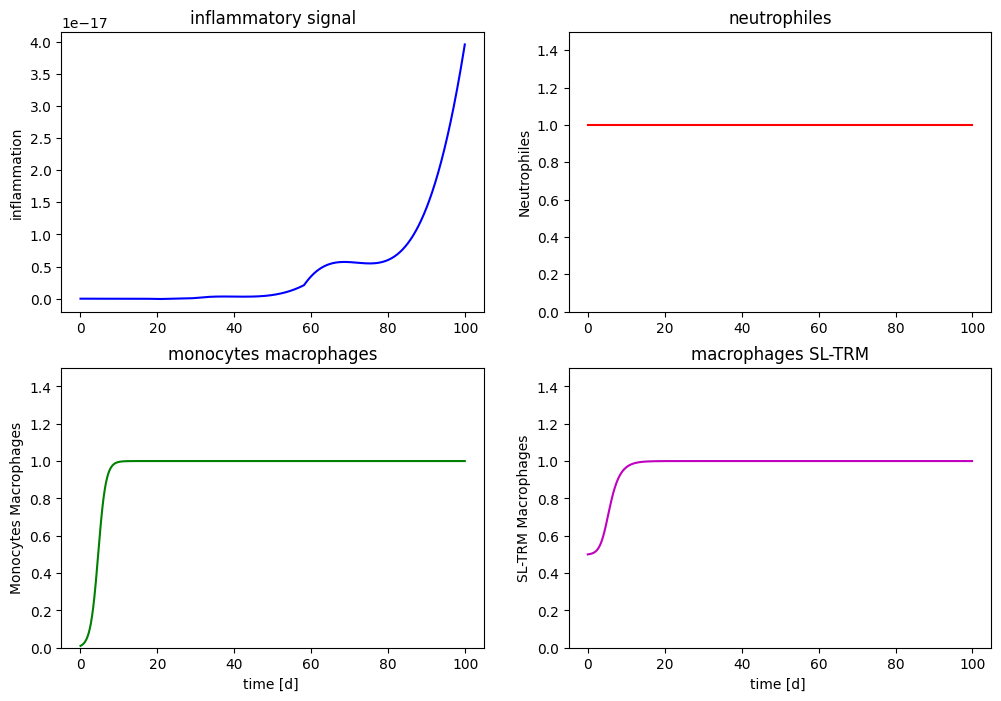

In [28]:
#test 10/10 brain storming pour instabilité des points fixes du type (0,1,0,T) avec T non nul <1
inflam_adim_andrea([0., 1, 0.01, 0.5],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1, delta_T=0.5, a=1, b=1, duree=100)


valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


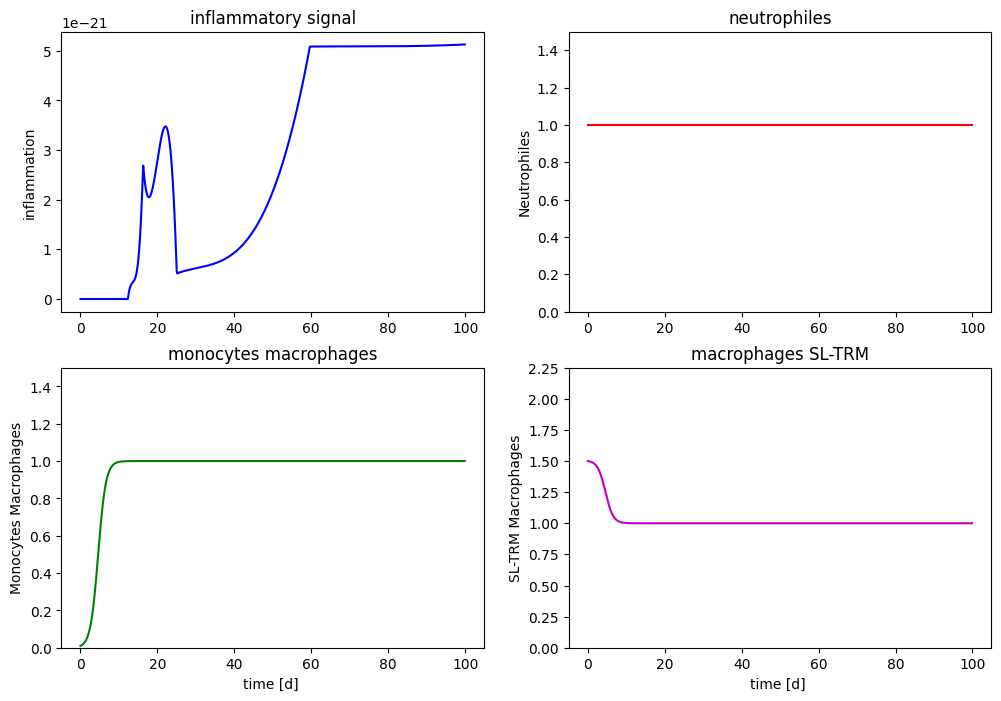

In [29]:
# test pour instabilité des points fixes du type (0,1,0,T) avec T_ini > 1
inflam_adim_oliv([0., 1, 0.01, 1.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=1, b=1, duree=100)

On remarque un phénomène intéressant: en l'absence de signal immun initial même en présence de Neutrophiles, l'état $(0,1, 0, T)$ évolue vers l'état physiologique.


valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


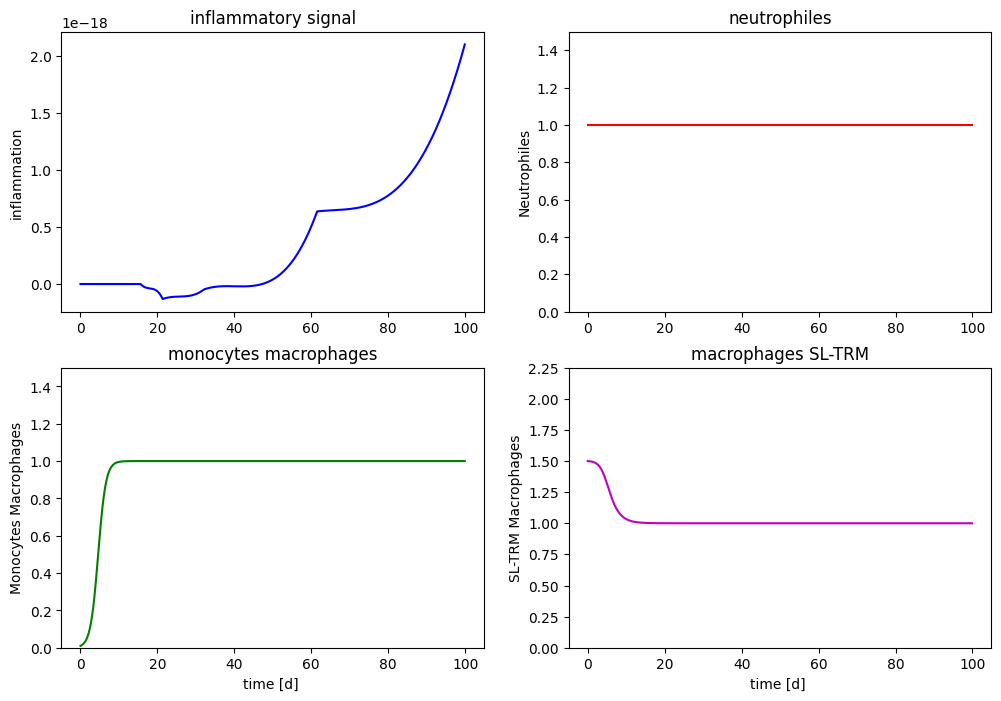

In [30]:
# test pour instabilité des points fixes du type (0,1,0,T) avec T_ini > 1
inflam_adim_andrea([0., 1, 0.01, 1.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1, delta_T=0.5, a=1, b=1, duree=100)

valeurs finales: Signal=1123.067, Neutrophiles=562.569, Momac=9.574, SL-TRM=0.014


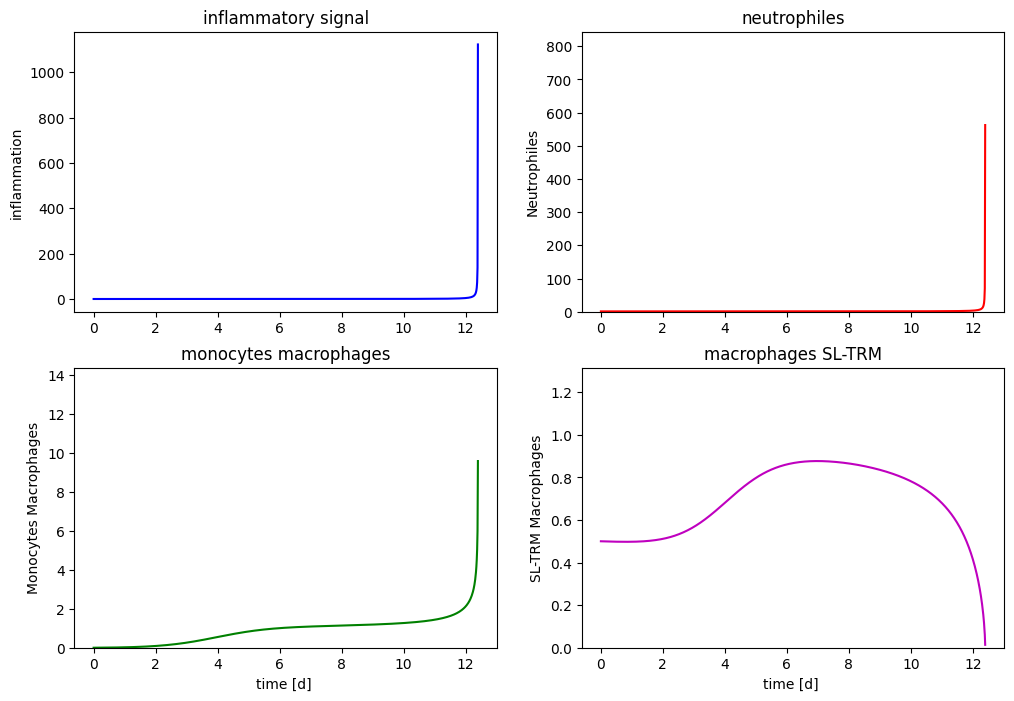

In [31]:
# test pour instabilité des points fixes du type (0,1,0,T) avec T_ini < 1
inflam_adim_oliv([0.01, 1, 0., 0.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=1, b=1, duree=12.5)

On voit un instabilité lorsque le patient a un stock insuffisant de SL-TRM (T) et des neutrophiles.

valeurs finales: Signal=250.204, Neutrophiles=126.149, Momac=6.921, SL-TRM=0.021


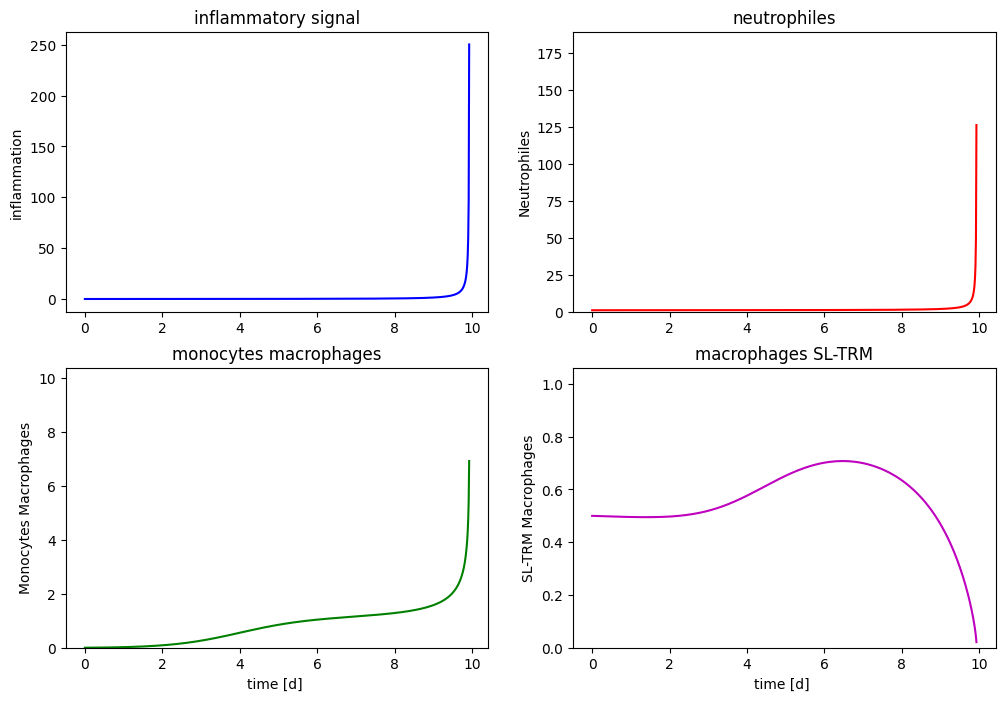

In [32]:
# test pour instabilité des points fixes du type (0,1,0,T) avec T_ini < 1
inflam_adim_andrea([0.01, 1, 0., 0.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1, delta_T=0.5, a=1, b=1, duree=12.5)

valeurs finales: Signal=0.001, Neutrophiles=1.001, Momac=1.001, SL-TRM=0.999


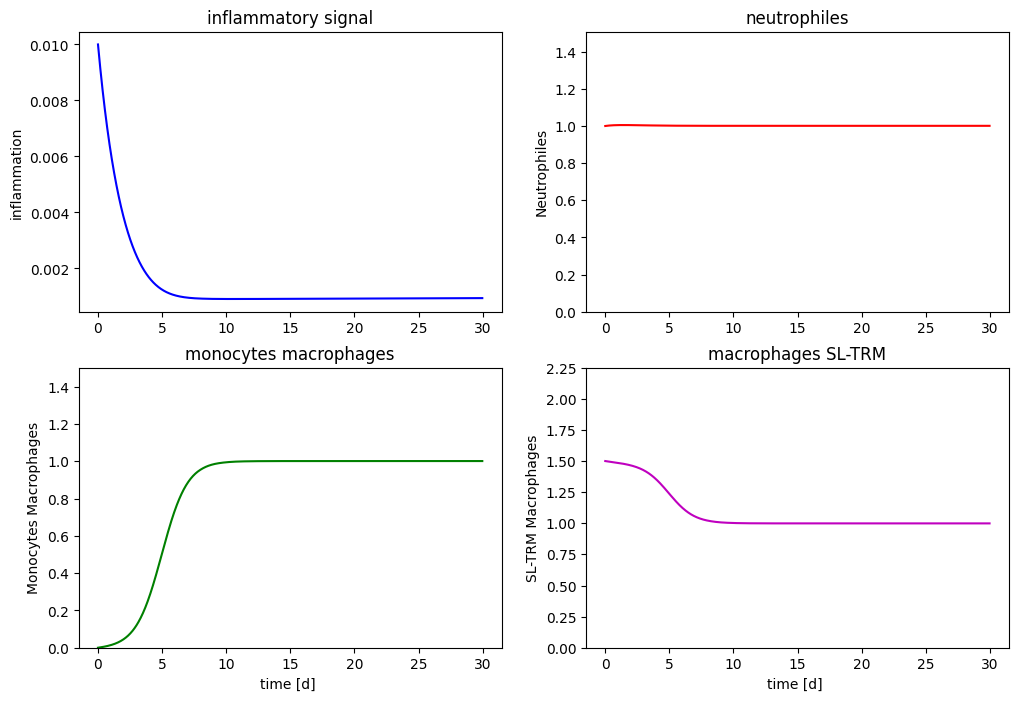

In [33]:
#instabilité des points fixes du type (0,1,0,T) avec T_ini > 1 
inflam_adim_oliv([0.01, 1, 0., 1.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=1, b=1, duree=30)


On trouve que la sous-variété $T=1$ est critique pour ce type de point fixe. En effet  lorsque $T>1$ le système revient à l'état physiologique. Alors que pour $T<1$ le système s'emballe. La crise s'amplifie

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=0.999


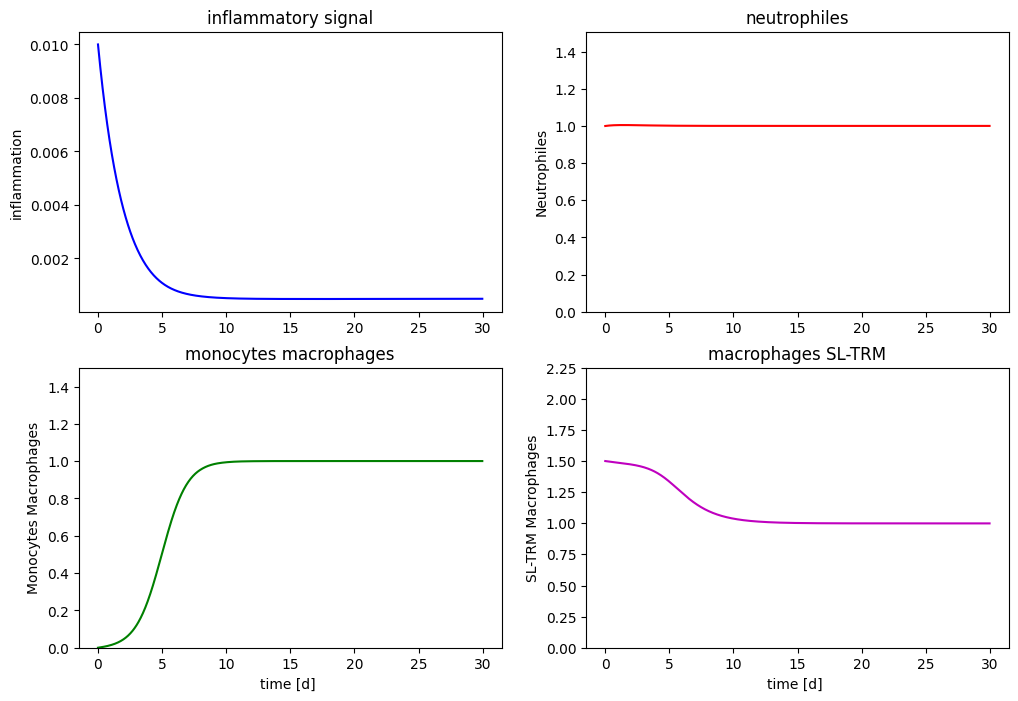

In [34]:
#instabilité des points fixes du type (0,1,0,T) avec T_ini > 1 
inflam_adim_andrea([0.01, 1, 0., 1.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1, delta_T=0.5, a=1, b=1, duree=30)


valeurs finales: Signal=0.004, Neutrophiles=1.015, Momac=1.014, SL-TRM=0.987


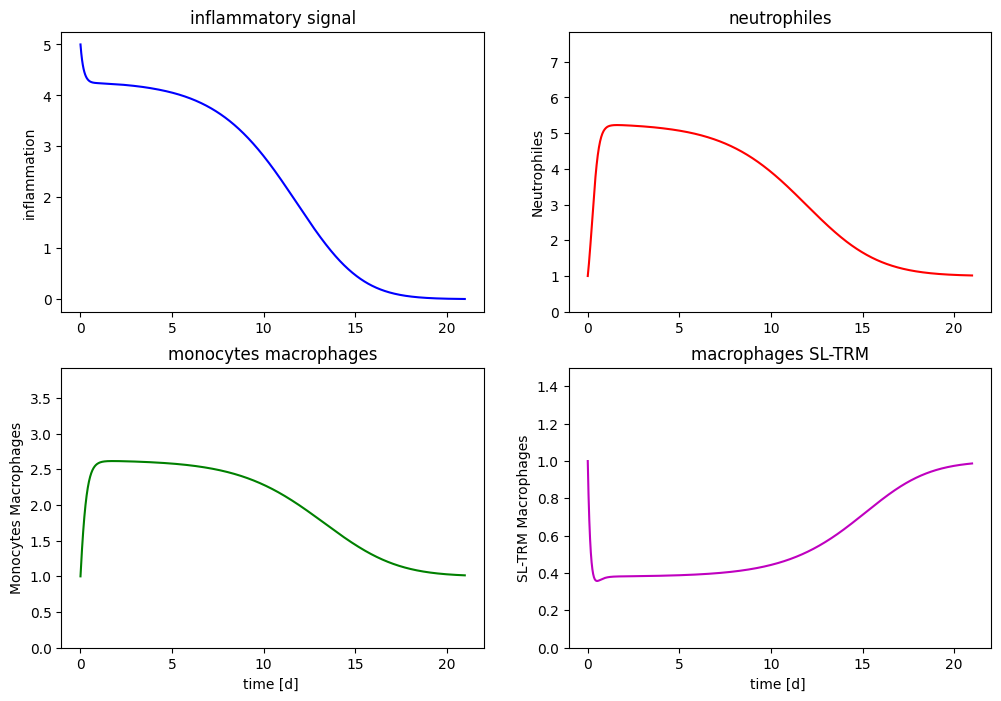

In [35]:
inflam_adim_oliv([5, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.072, b=1, duree=21)

valeurs finales: Signal=15505.437, Neutrophiles=14465.029, Momac=50.603, SL-TRM=0.002


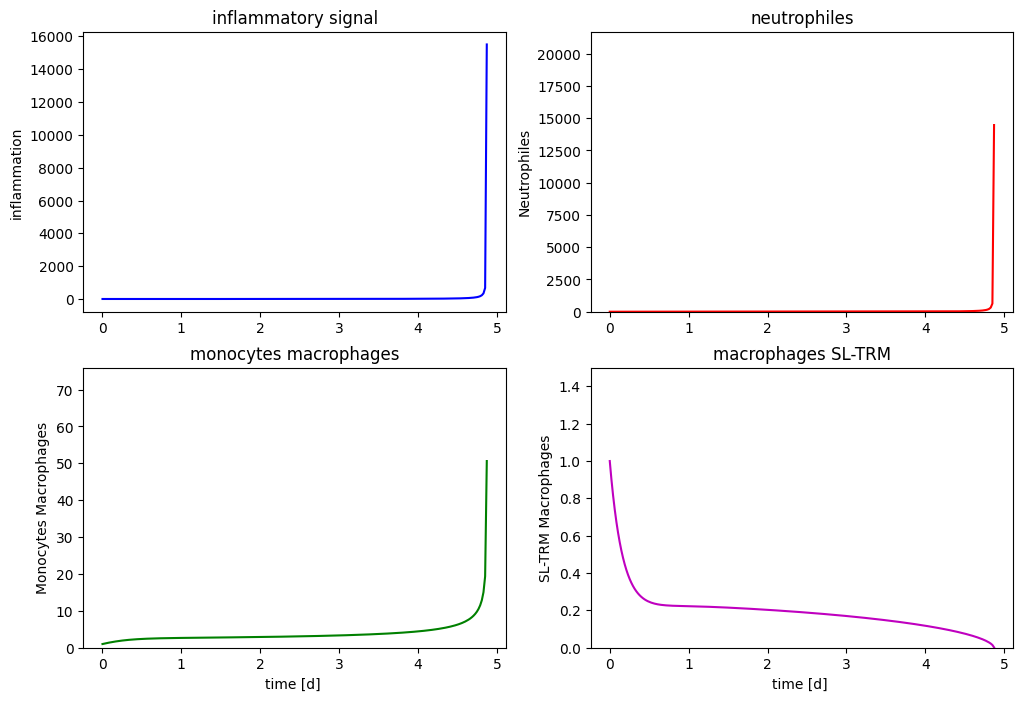

In [36]:
inflam_adim_andrea([5, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1, delta_T=0.5, a=0.072, b=1, duree=21)

valeurs finales: Signal=0.001, Neutrophiles=1.004, Momac=1.004, SL-TRM=0.972


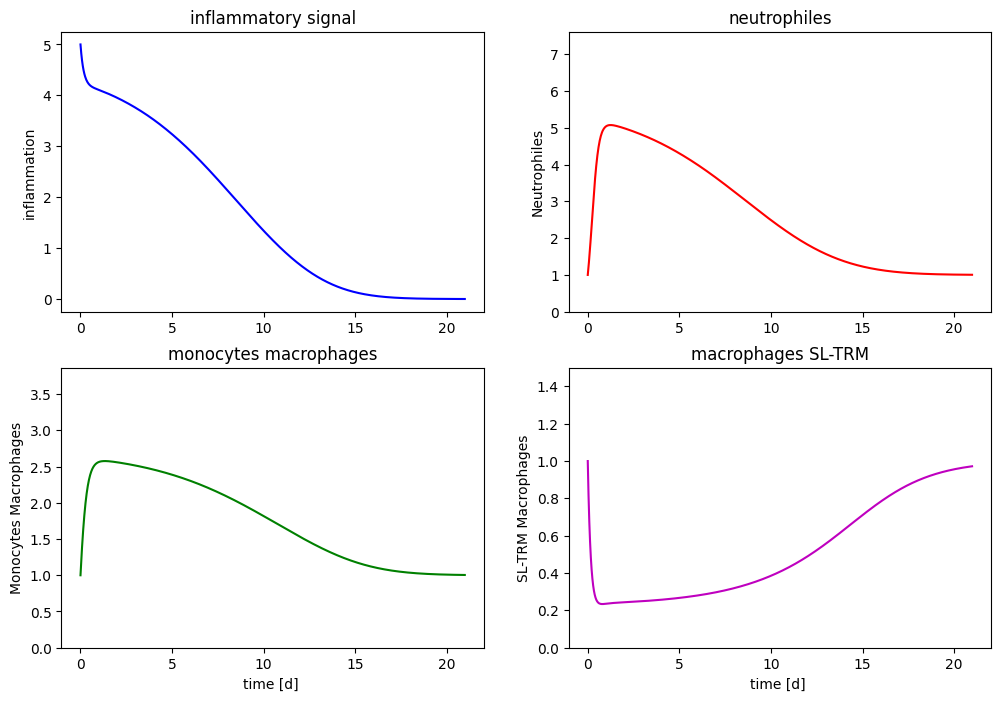

In [37]:
inflam_adim_andrea([5, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1, delta_T=0.5, a=0.04, b=1, duree=21)

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


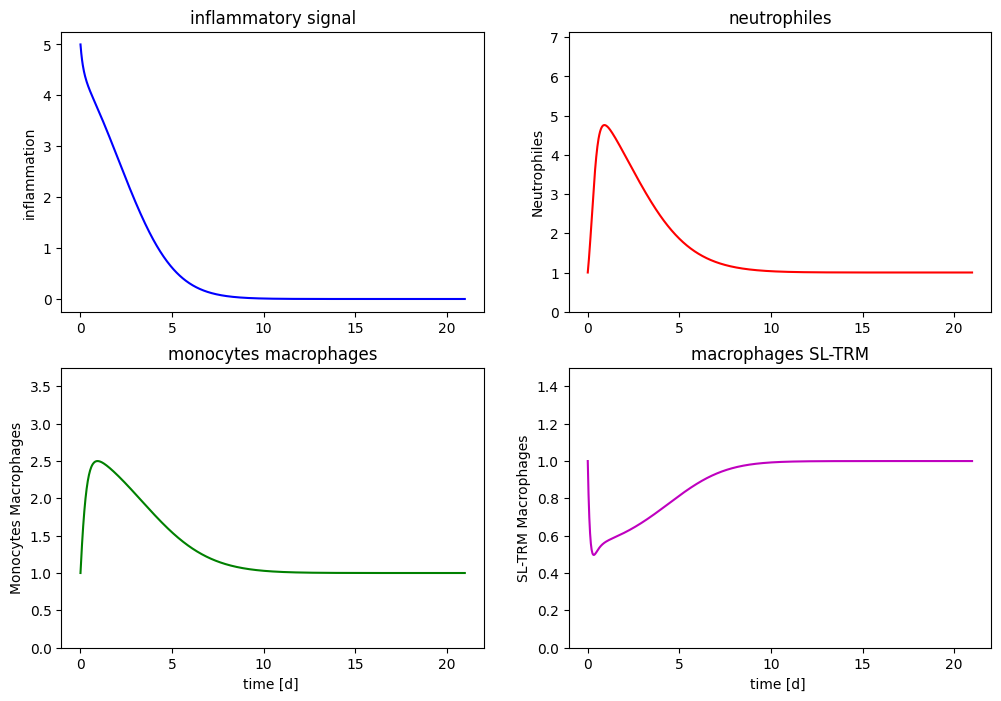

In [38]:
inflam_adim_andrea([5, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1, delta_T=2, a=0.072, b=1, duree=21)

En comparant le systeme avec $\delta_T \neq \delta_M$ on trouve des résultats analogues, cependant il faut diminuer parfois le rapport $a/b$ pour retrouver le même comportement. Le bassin d'attraction du régime (0,1,1,1) est plus petit apparemment.

valeurs finales: Signal=0.021, Neutrophiles=1.067, Momac=1.058, SL-TRM=0.951


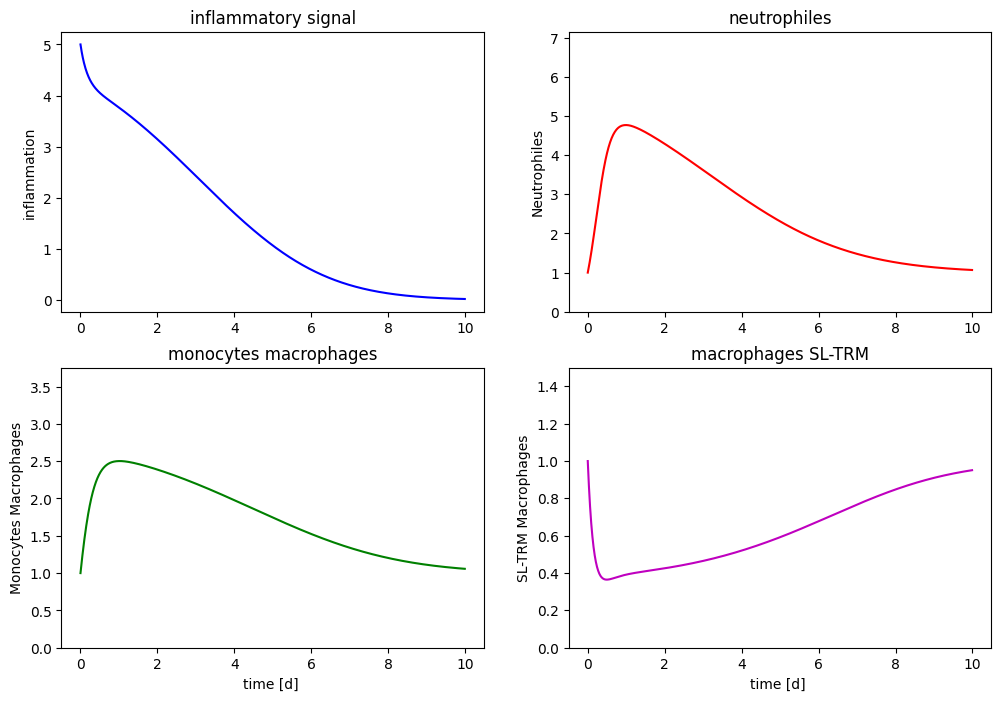

In [39]:
inflam_adim_degrad([5, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=0.072, b=1, c=0.1, duree=10)

## 7. Créer une interface interactive pour explorer le modèle

Utilisez les curseurs pour explorer dynamiquement l'effet des paramètres sur le modèle.

In [40]:
# Définition de la fonction interactive
def interactive_inflam_oliv(alpha,beta,gamma,delta_N,delta_M, a, b, duree):
    inflam_adim_oliv([1, 1.00, 1, 1],
           alpha, beta, gamma, delta_N, delta_M, a, b, duree)

# Création des curseurs pour les paramètres
ui = widgets.HBox([
    widgets.VBox([
        widgets.FloatSlider(min=0, max=100, step=0.01, value=1, description='alpha neutrophiles <-signal'),
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='beta Momac <- neutrophiles'),
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='gamma  SL-TRM <- signal'),
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='delta_N  neutrophiles'),
    ]),
    widgets.VBox([
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='delta_M conversion  Momac -> SL-TRM'),
        widgets.FloatSlider(min=0, max=1, step=0.01, value=0.35, description='a feed-back neutrophiles -> signal'),
        widgets.FloatSlider(min=0, max=1, step=0.01, value=1, description='b hold-back SL-TRM -> signal'),
        widgets.IntSlider(min=0, max=20, step=1, value=10, description='durée de la simulation'),
    ])
])

out = widgets.interactive_output(
    interactive_inflam_oliv,
    {
        'alpha': ui.children[0].children[0],
        'beta': ui.children[0].children[1],
        'gamma': ui.children[0].children[2],
        'delta_N': ui.children[0].children[3],
        'delta_M': ui.children[1].children[0],
        'a': ui.children[1].children[1],
        'b': ui.children[1].children[2],
        'duree': ui.children[1].children[3],
    }
)

display(ui, out)

Output()

Il faut étudier avec précision les équilibres et les conditions de stabilité du système.

valeurs finales: Signal=0.149, Neutrophiles=1.151, Momac=1.070, SL-TRM=0.877


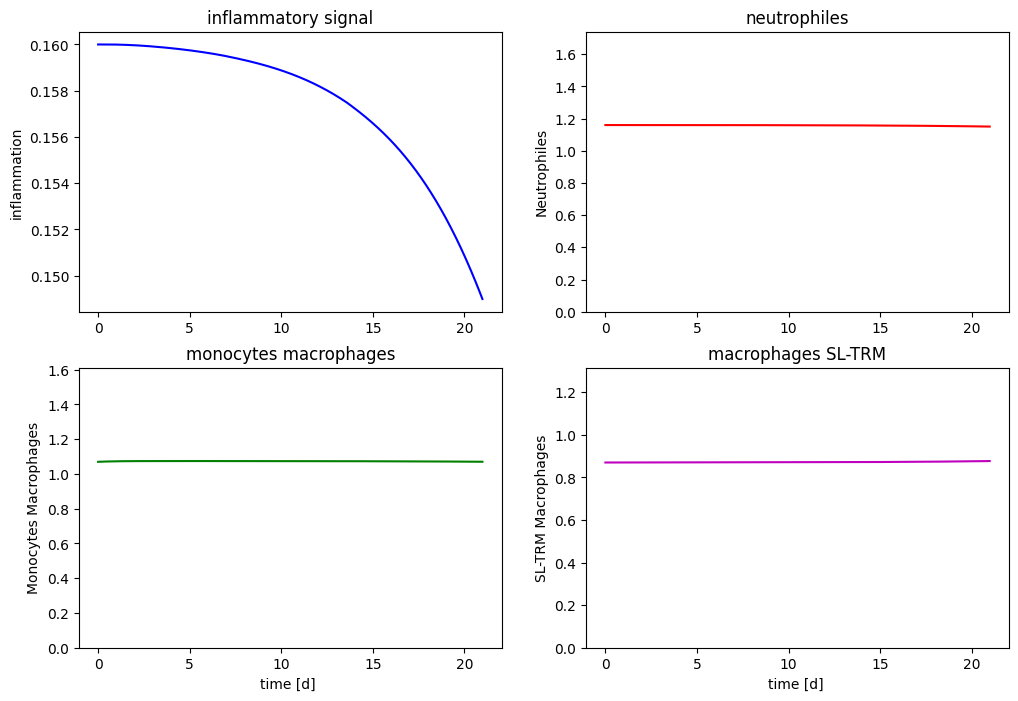

In [41]:
inflam_adim_oliv([0.16, 1.16, 1.07, 0.87],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.75, b=1, duree=21)


Il semble que la trajectoire soit attirée par le point fixe homéostasique $(0,1,1,1)$
Cependant si on double la dose de sérum immun, le scénario est différent:

valeurs finales: Signal=857.395, Neutrophiles=490.962, Momac=5.953, SL-TRM=0.010


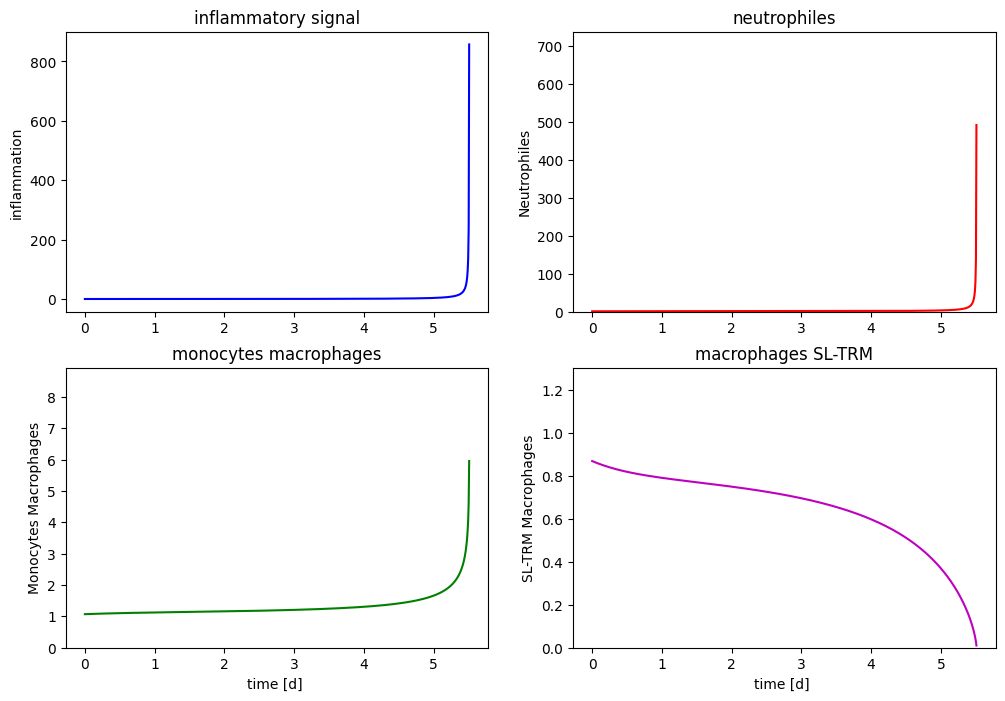

In [42]:
inflam_adim_oliv([0.32, 1.16, 1.07, 0.87],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.75, b=1, duree=7)


On peut aussi augmenter le pouvoir anti-inflammatoire des macrophages SL-TRM

valeurs finales: Signal=0.070, Neutrophiles=1.093, Momac=1.045, SL-TRM=0.920


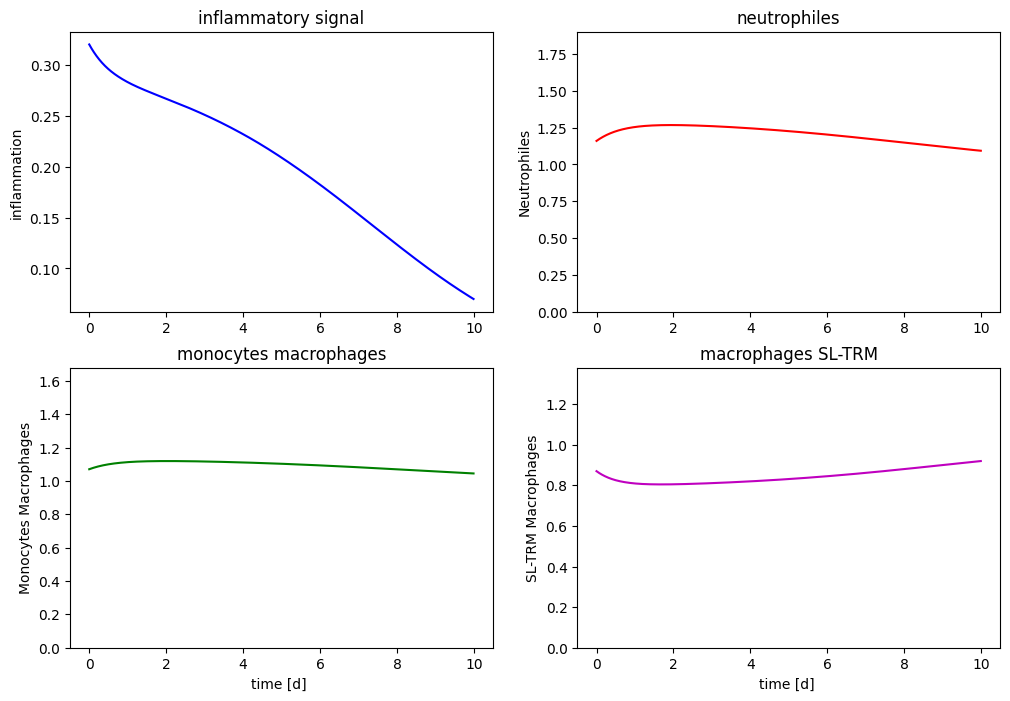

In [43]:
inflam_adim_oliv([0.32, 1.16, 1.07, 0.87],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.75, b=1.25, duree=10)


ou diminuer la rétro-action inflammatoire des neutrophiles

valeurs finales: Signal=0.044, Neutrophiles=1.066, Momac=1.032, SL-TRM=0.942


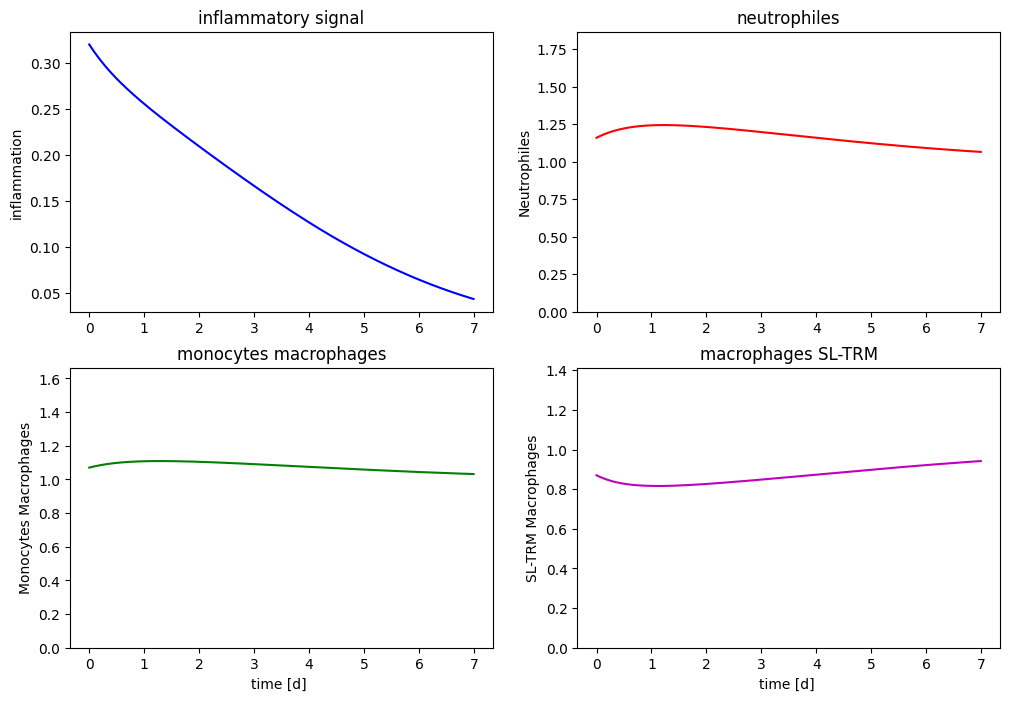

In [44]:
inflam_adim_oliv([0.32, 1.16, 1.07, 0.87],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.5, b=1, duree=7)


valeurs finales: Signal=536.202, Neutrophiles=307.432, Momac=5.450, SL-TRM=0.015


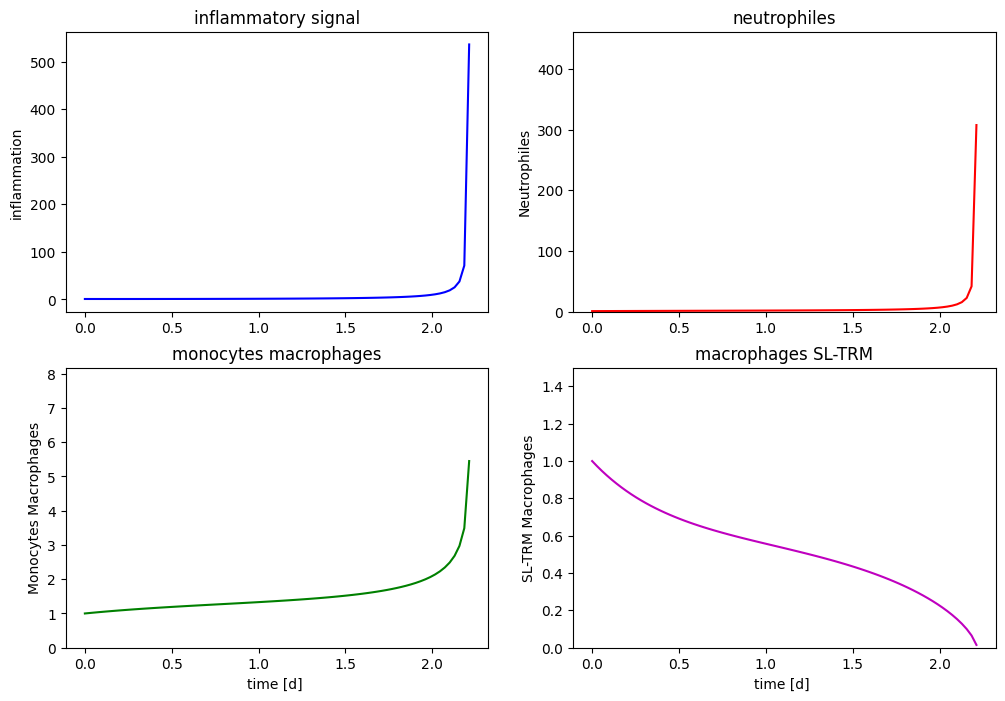

In [45]:
inflam_adim_oliv([1+1e-3, 1, 1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.75, b=1, duree=28)

On constate que la crise d'arthrite s'emballe dans ce cas.

valeurs finales: Signal=292.232, Neutrophiles=168.035, Momac=4.821, SL-TRM=0.024


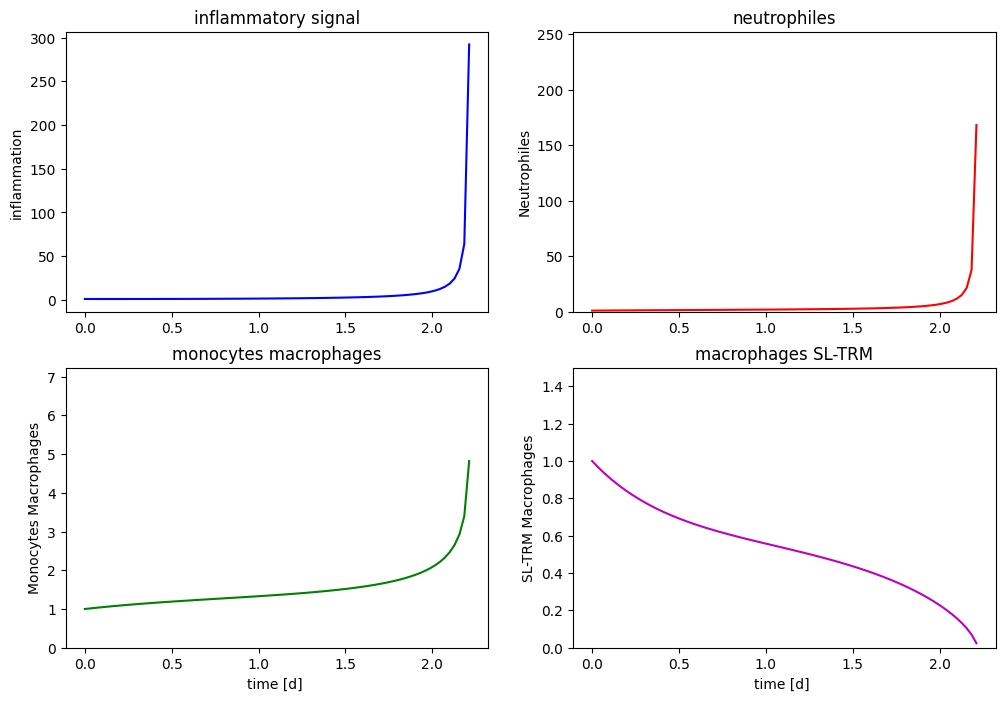

In [46]:
inflam_adim_oliv([1-1e-3, 1, 1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.75, b=1, duree=28)

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


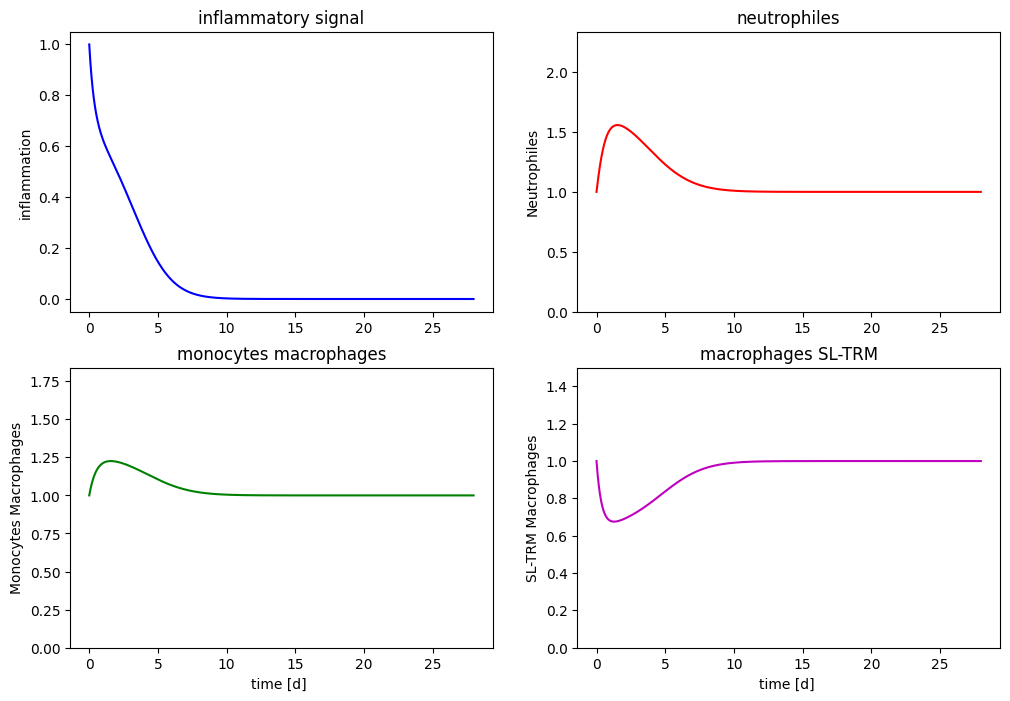

In [47]:
inflam_adim_degrad([1-1e-3, 1, 1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.75, b=1, c=0.7, duree=28)

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


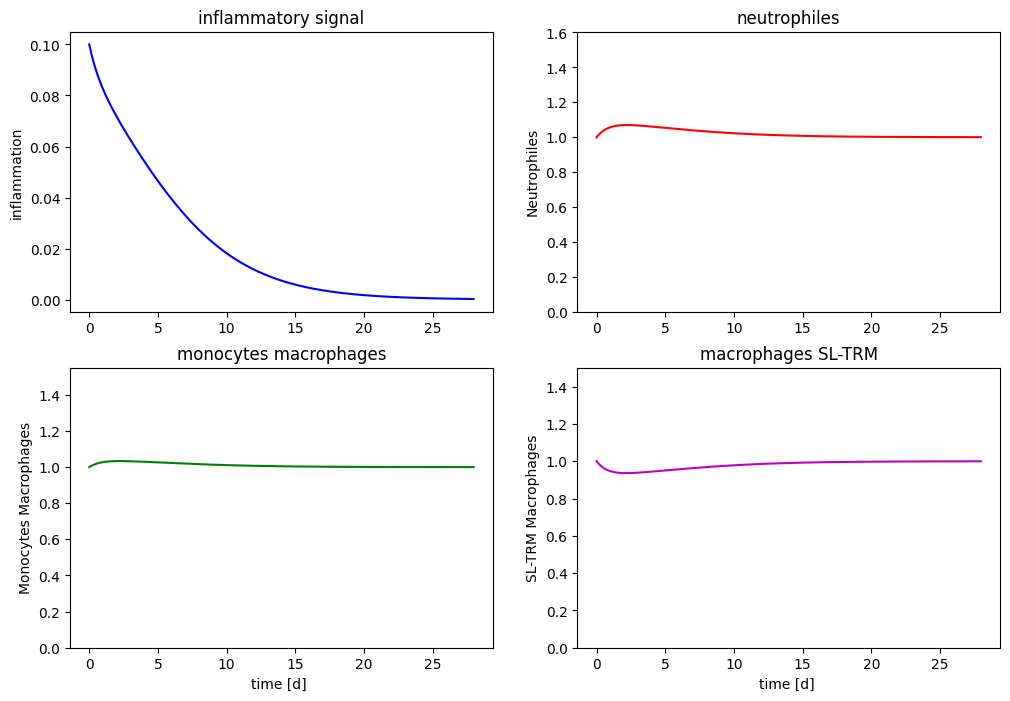

In [48]:
inflam_adim_oliv([0.1, 1-1e-3, 1, 1+1e-3],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.75, b=1, duree=28)

valeurs finales: Signal=536.202, Neutrophiles=307.432, Momac=5.450, SL-TRM=0.015


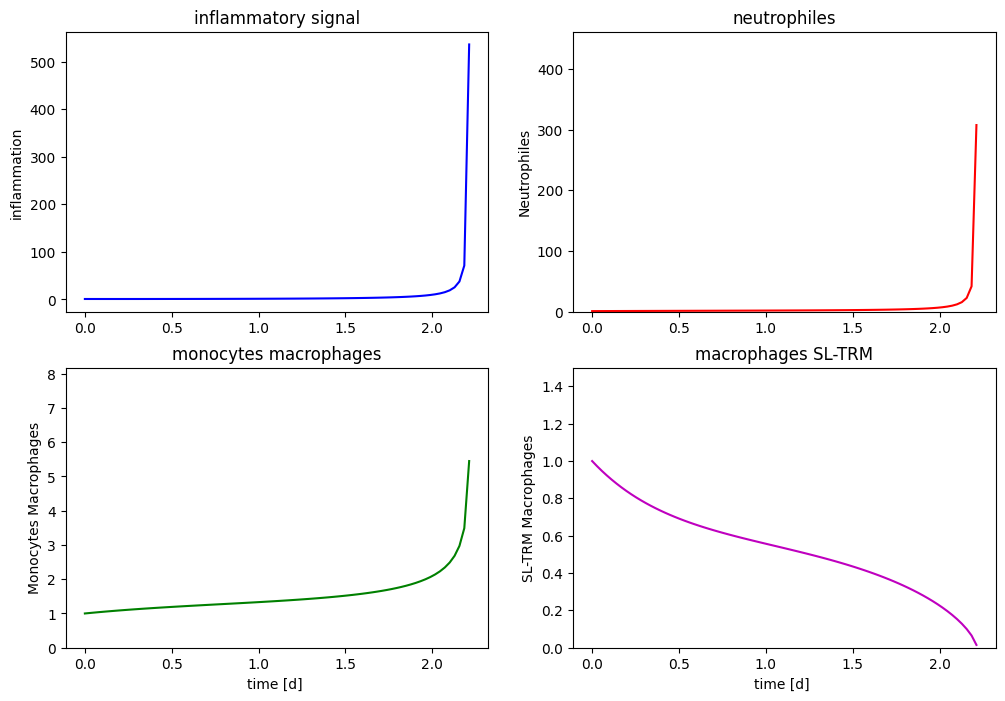

In [49]:
inflam_adim_oliv(
    [1 + 1e-3, 1, 1, 1],
    alpha=1,
    beta=0.5,
    gamma=1,
    delta_N=1,
    delta_M=1,
    a=0.75,
    b=1,
    duree=28
)

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


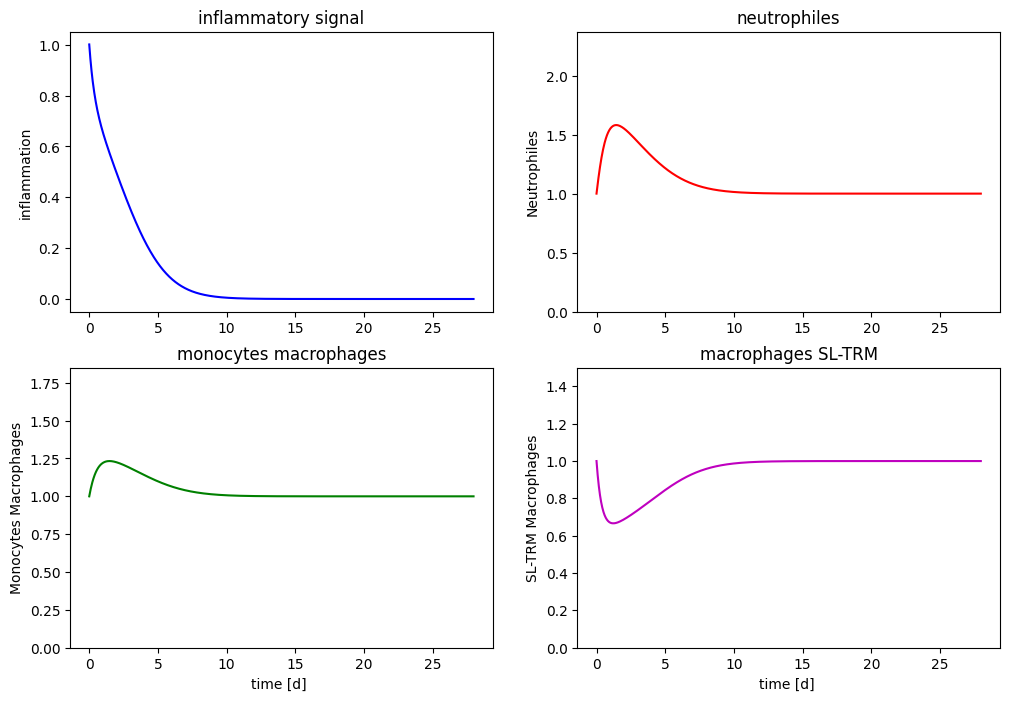

In [50]:
inflam_adim_oliv([1+1e-3, 1, 1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.25, b=1, duree=28)

on remarque que la valeur de $a$ est critique pour la résolution de la crise. Si $a$ décroît l'équilibre homéostasique est de plus en plus attractif.

La question se pose : y a-t-il des points d'équilibres stables avec $S\neq 0$?


Pour résumer si $a>b$ i.e. $A>1$ il y a un seul point d'equilibre, c'est l'état homéostasique mais il est instable

valeurs finales: Signal=2.961, Neutrophiles=2.613, Momac=1.498, SL-TRM=0.439


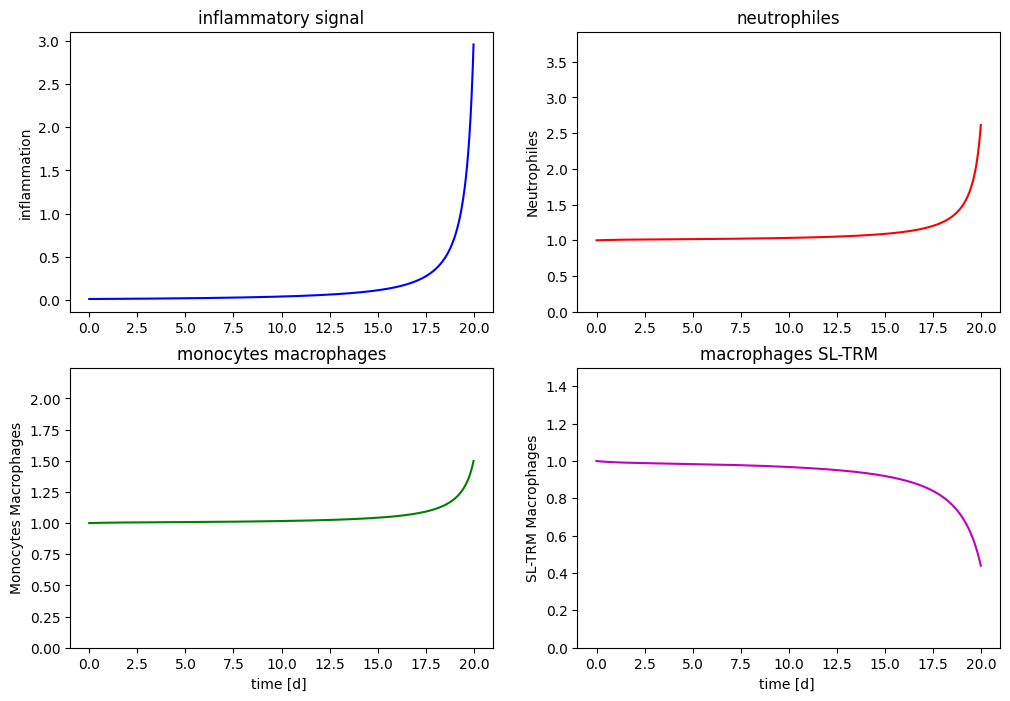

In [51]:
inflam_adim_oliv([0.01, 1, 1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=1.1, b=1, duree=20)

Pour $a<b$ i.e. pour $A<1$ il y a deux équilibres, l'équilibre homeostasique qui est **stable** et un autre équilibre maladie chronique avec $S\neq 0$ qui est instable. Plus $a/b$ est petit plus le bassin d'attraction de l'équilibre homéostasique est grand

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


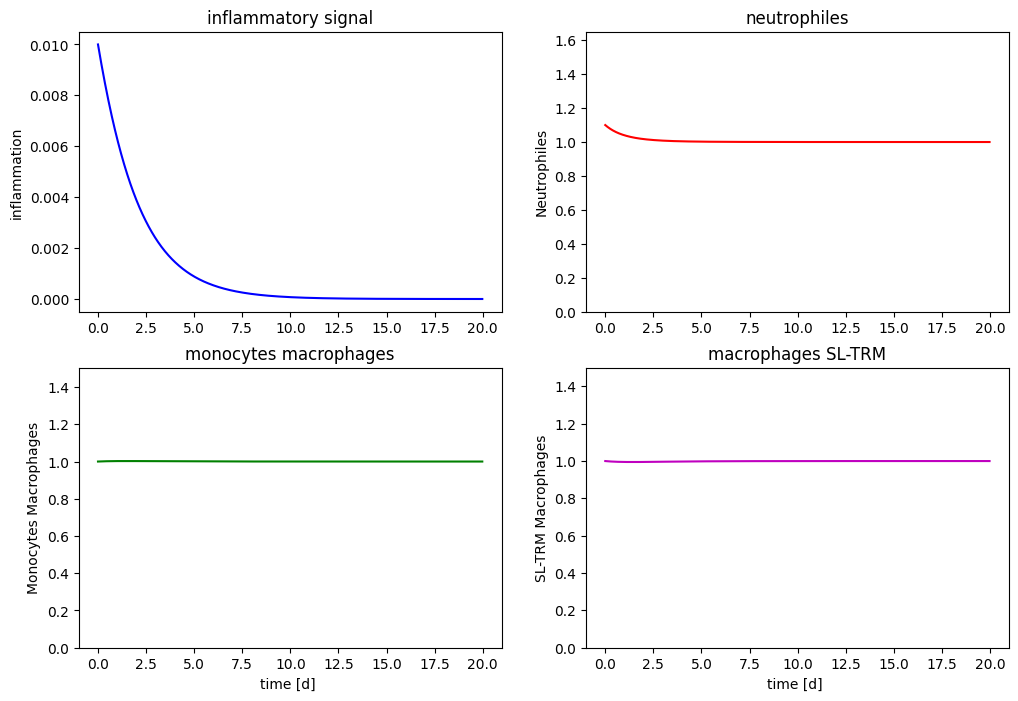

In [52]:
inflam_adim_oliv([0.01, 1.1, 1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.5, b=1, duree=20)

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


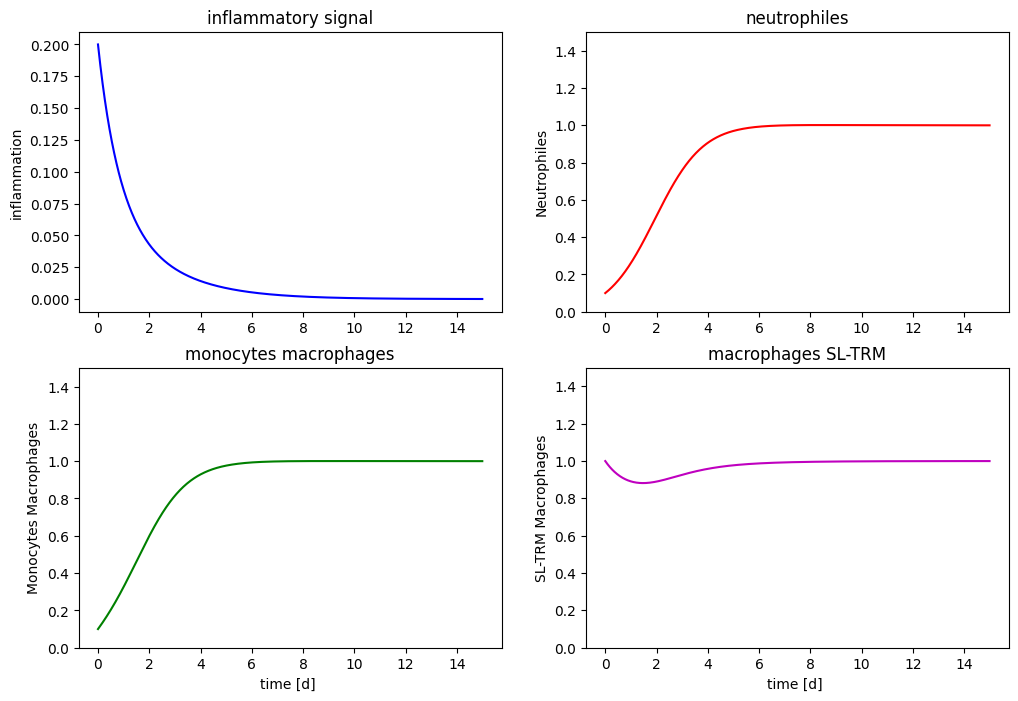

In [53]:
inflam_adim_oliv([0.2, 0.1, 0.1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.5, b=1, duree=15)

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


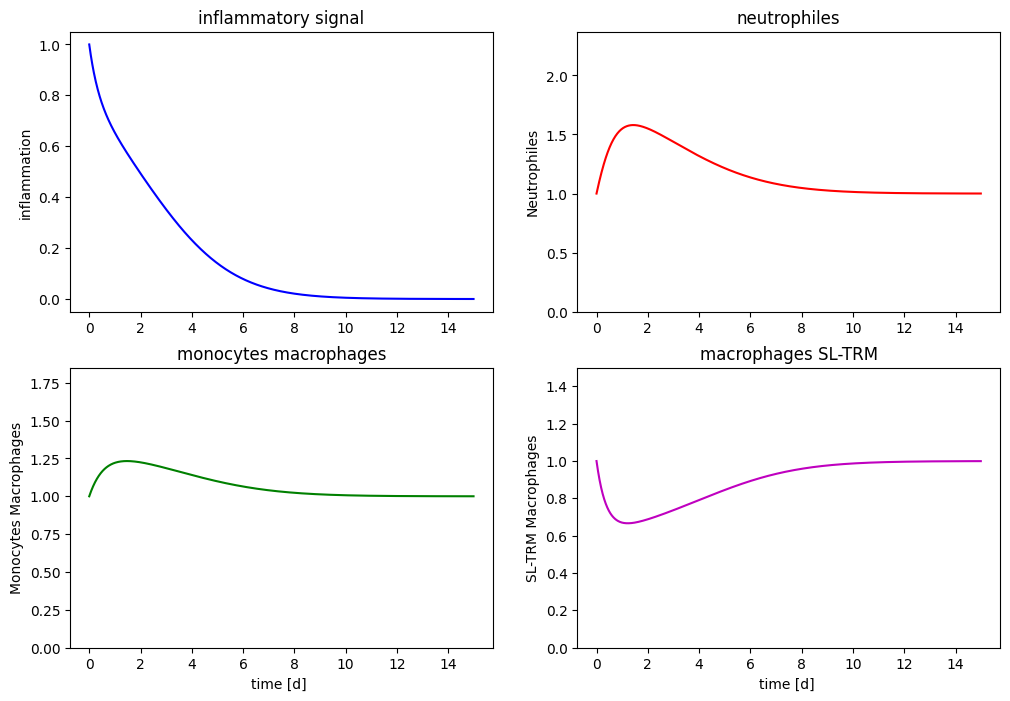

In [54]:
inflam_adim_oliv([1, 1, 1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.25, b=1, duree=15)

Le cas $a=b$ i.e. $A=1$ est critique. Il y a un seul équilibre, l'équilibre homéostasique mais il est **instable**

valeurs finales: Signal=4.499, Neutrophiles=3.487, Momac=2.166, SL-TRM=0.402


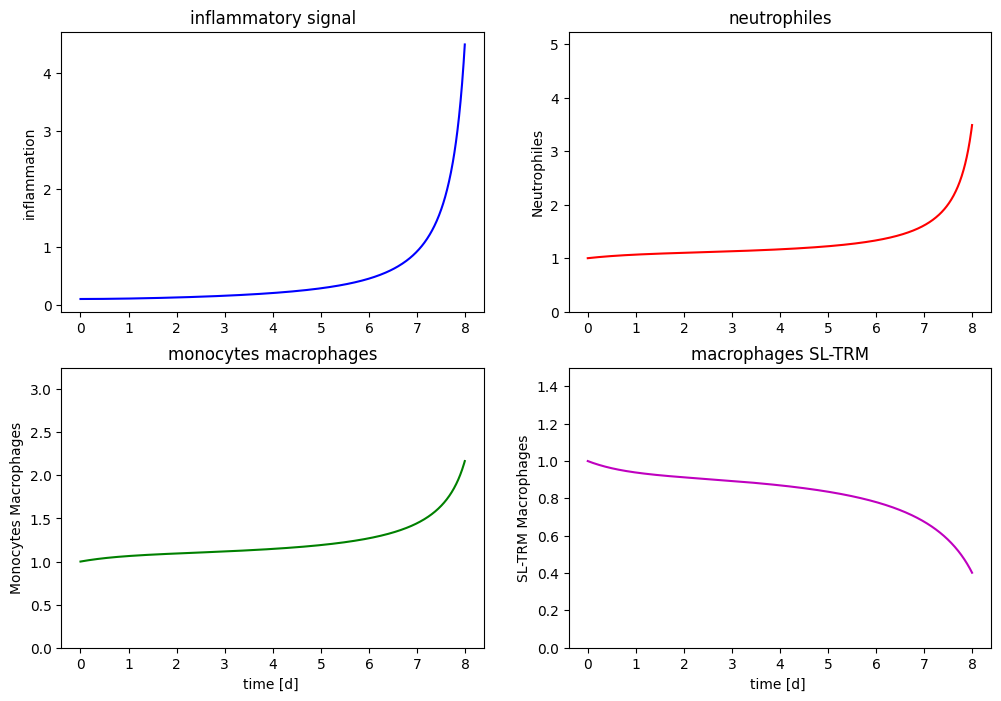

In [55]:
inflam_adim_oliv([0.1, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=1, b=1, duree=8)

valeurs finales: Signal=0.058, Neutrophiles=1.058, Momac=1.028, SL-TRM=0.946


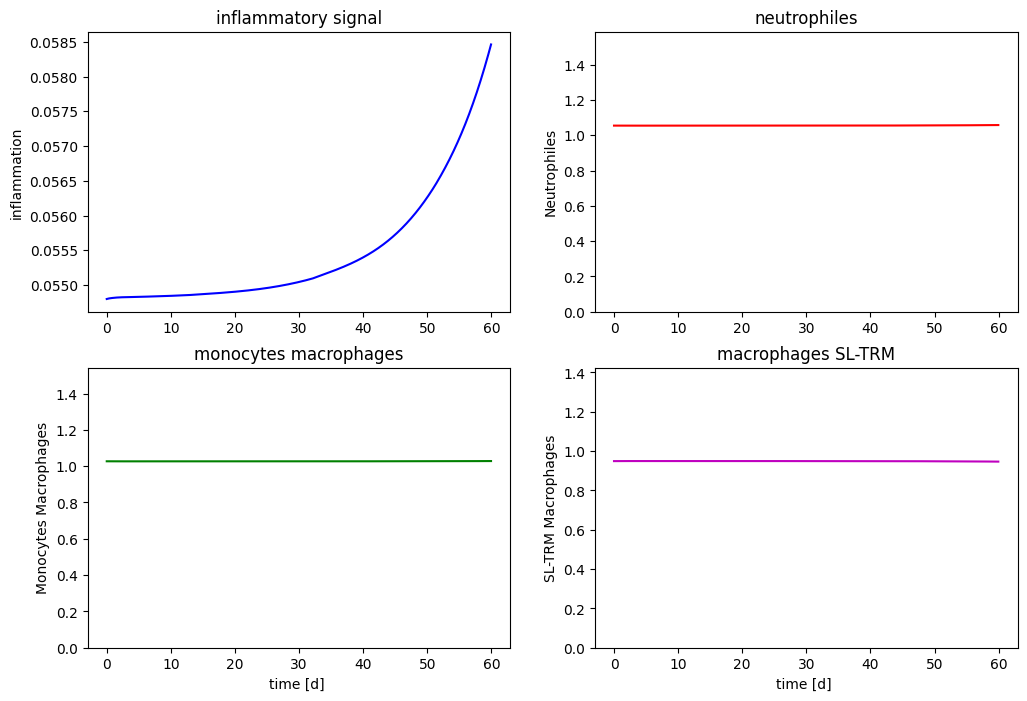

In [56]:
inflam_adim_oliv([0.0548, 1.055, 1.027, 0.949],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.9, b=1, duree=60)

valeurs finales: Signal=37.953, Neutrophiles=21.065, Momac=2.860, SL-TRM=0.055


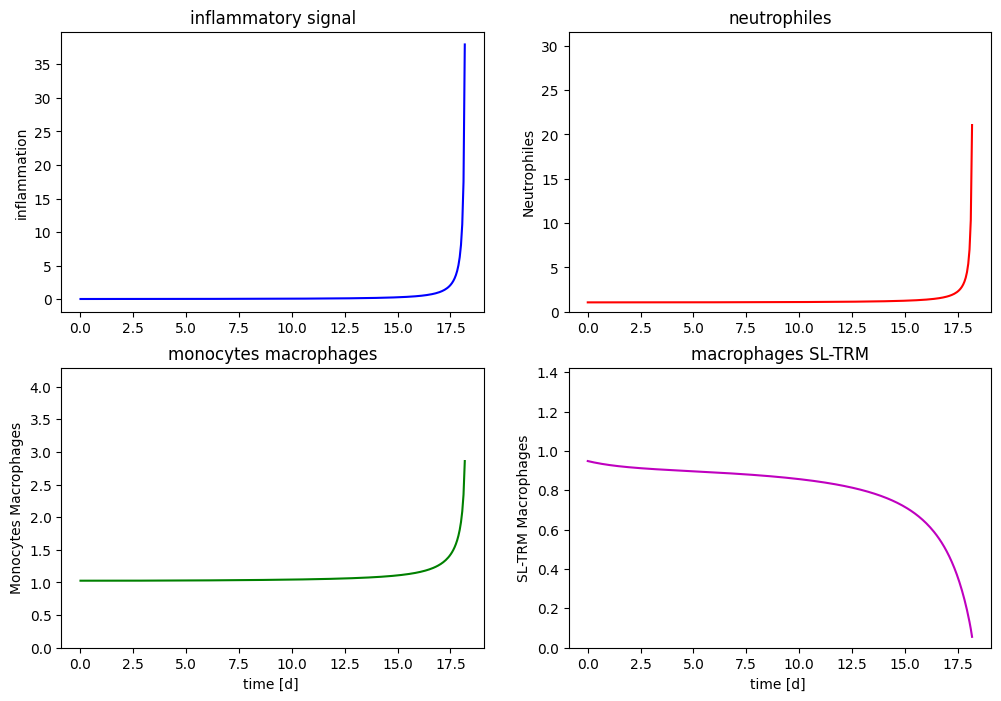

In [57]:
inflam_adim_andrea([0.0548, 1.055, 1.027, 0.949],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,delta_T=0.5, a=0.9, b=1, duree=60)

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


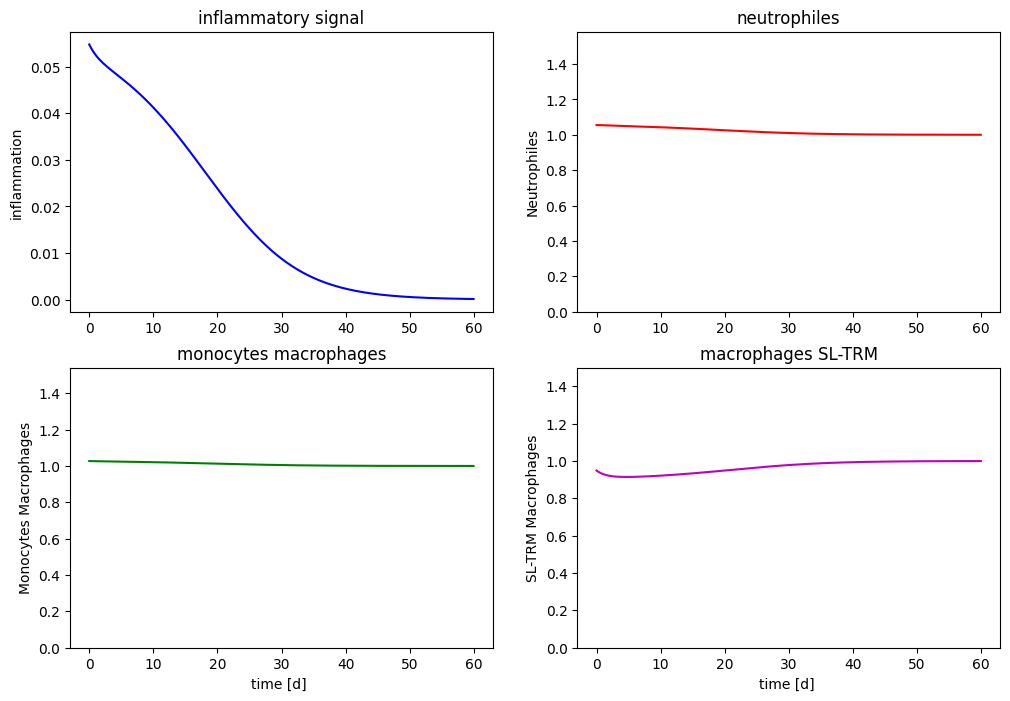

In [58]:
inflam_adim_andrea([0.0548, 1.055, 1.027, 0.949],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,delta_T=0.5, a=0.85, b=1, duree=60)

valeurs finales: Signal=243.417, Neutrophiles=153.180, Momac=4.946, SL-TRM=0.027


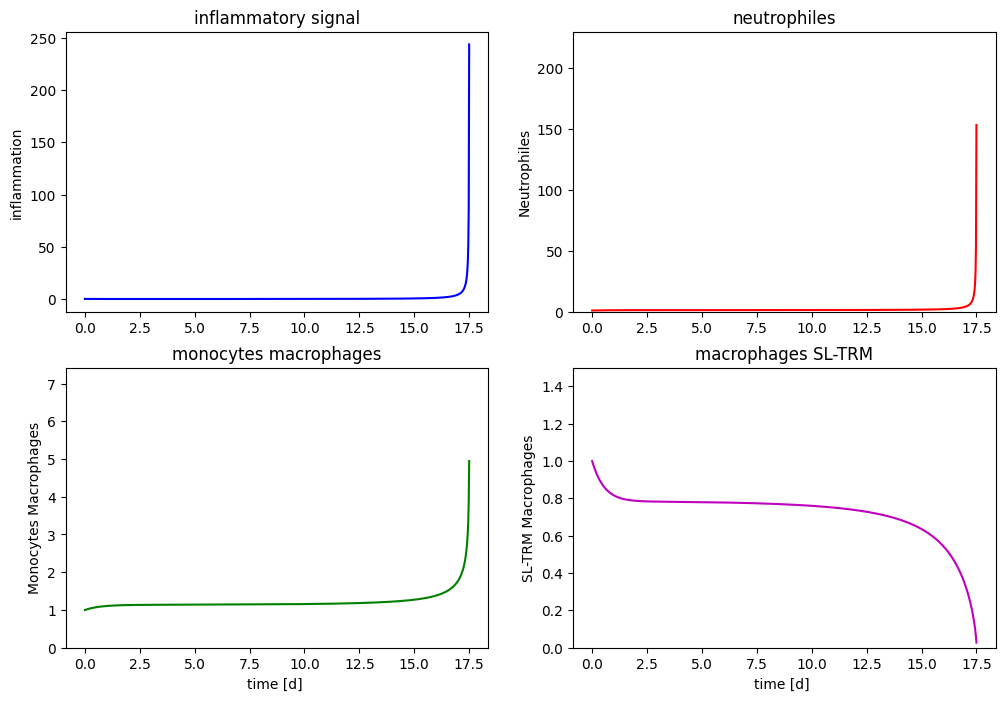

In [59]:
inflam_adim_oliv([0.4, 1, 1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.6, b=1, duree=20)

valeurs finales: Signal=140.846, Neutrophiles=89.063, Momac=4.349, SL-TRM=0.021


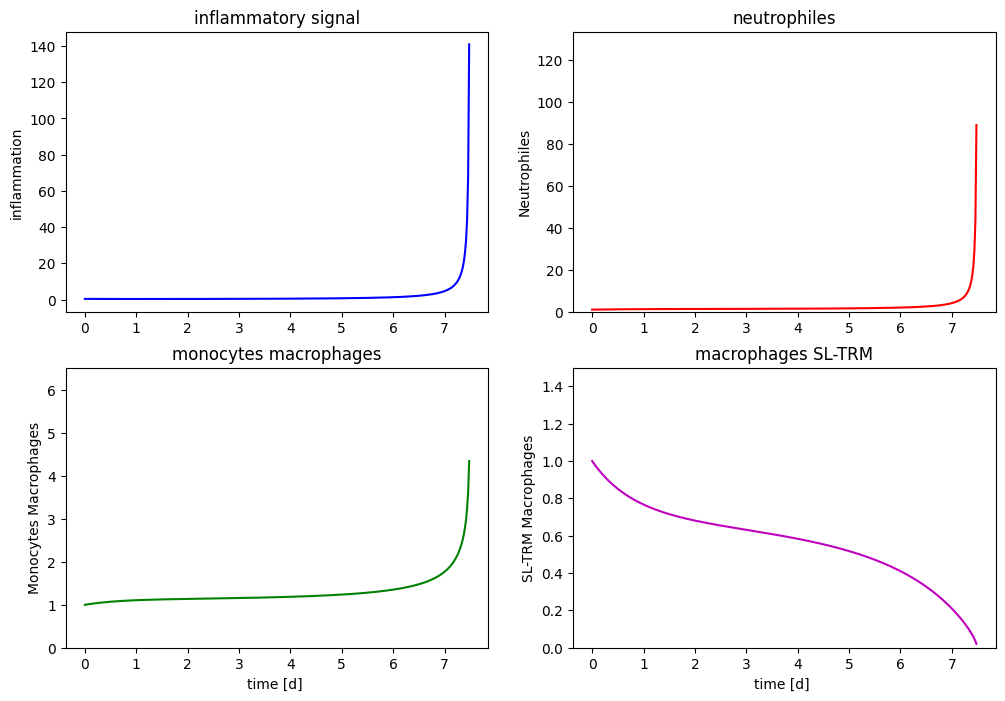

In [60]:
inflam_adim_andrea([0.4, 1, 1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,delta_T=0.5, a=0.6, b=1, duree=20)

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


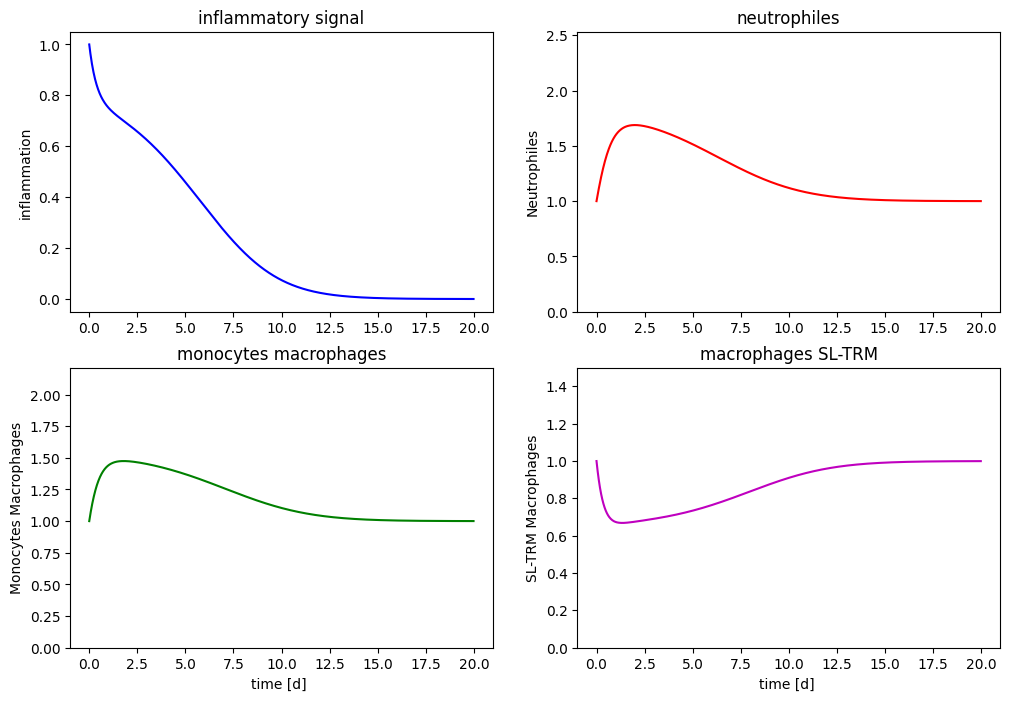

In [61]:
inflam_adim_oliv([1, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.35, b=1, duree=20) 
 

valeurs finales: Signal=0.011, Neutrophiles=1.023, Momac=1.022, SL-TRM=0.932


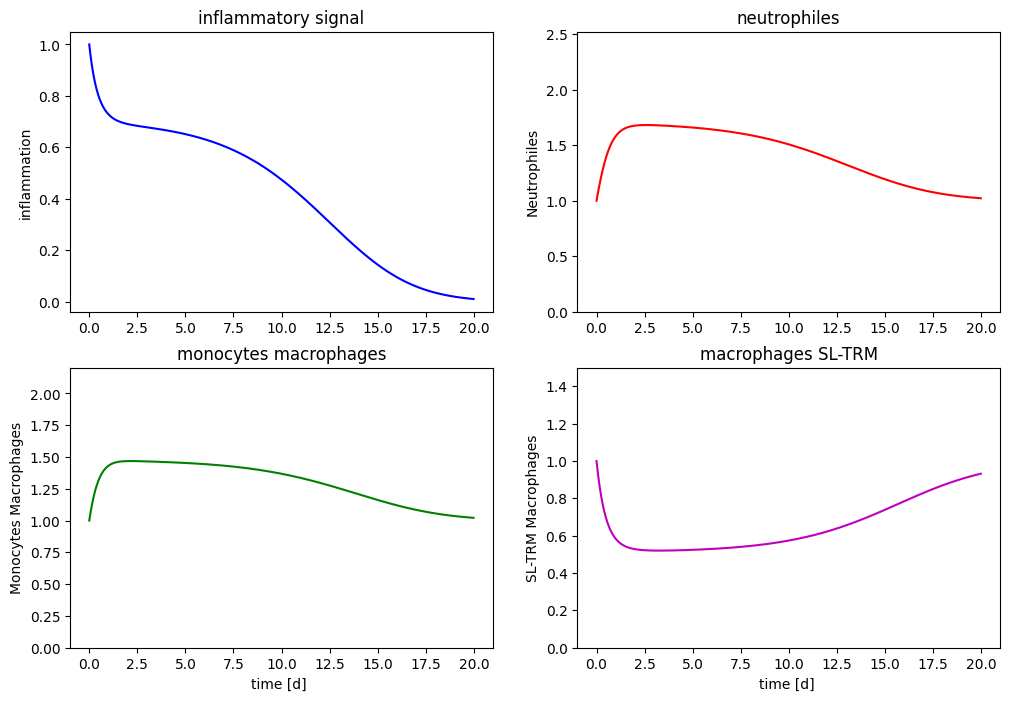

In [62]:
inflam_adim_andrea([1, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,delta_T=0.5, a=0.3, b=1, duree=20) 
 

valeurs finales: Signal=1093.401, Neutrophiles=793.340, Momac=13.215, SL-TRM=0.015


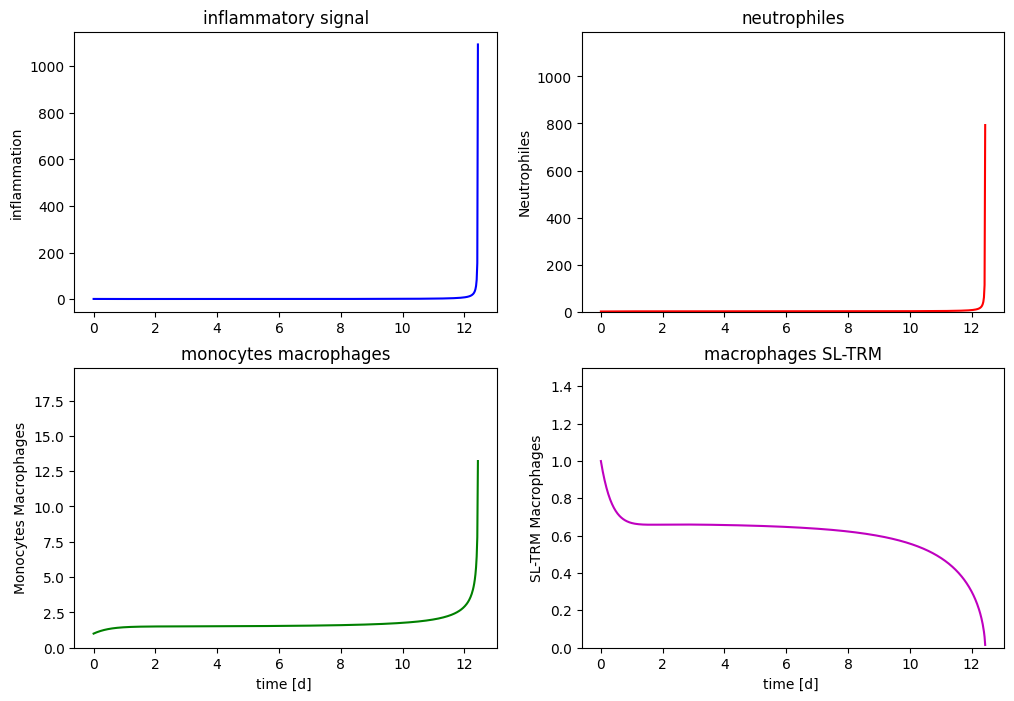

In [63]:
inflam_adim_oliv([1, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.38, b=1, duree=20) 
 

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


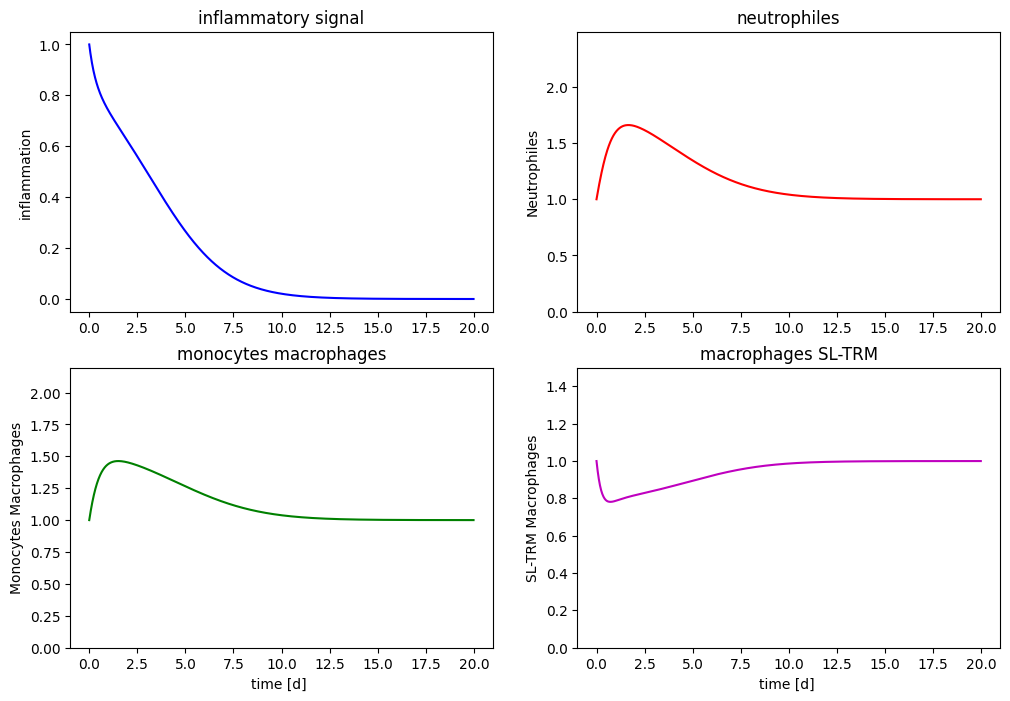

In [64]:
inflam_adim_andrea([1, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,delta_T=2, a=0.38, b=1, duree=20) 
 

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


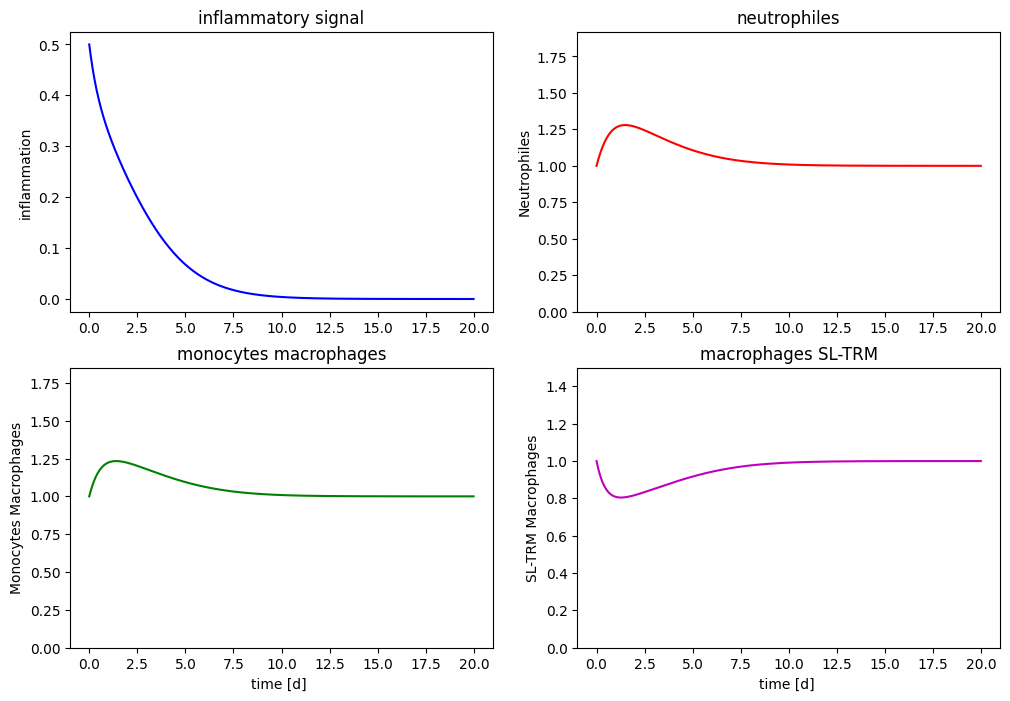

In [65]:
inflam_adim_oliv([0.5, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.38, b=1, duree=20) 
 

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=0.999


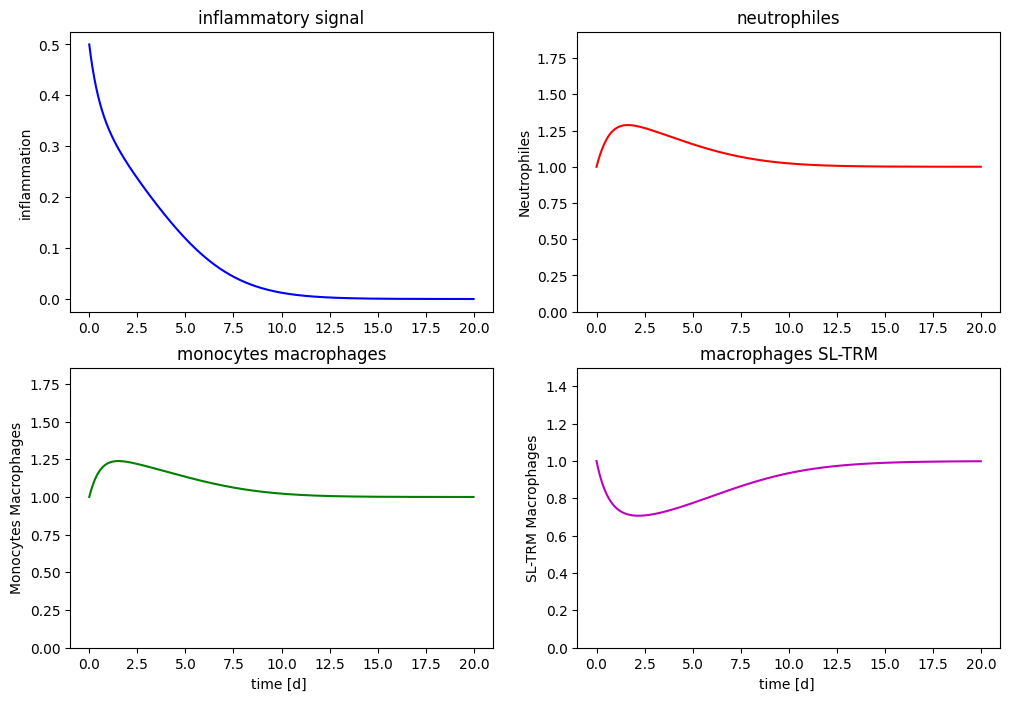

In [66]:
inflam_adim_andrea([0.5, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,delta_T=0.5, a=0.38, b=1, duree=20) 
 

valeurs finales: Signal=1036.841, Neutrophiles=752.356, Momac=13.051, SL-TRM=0.016


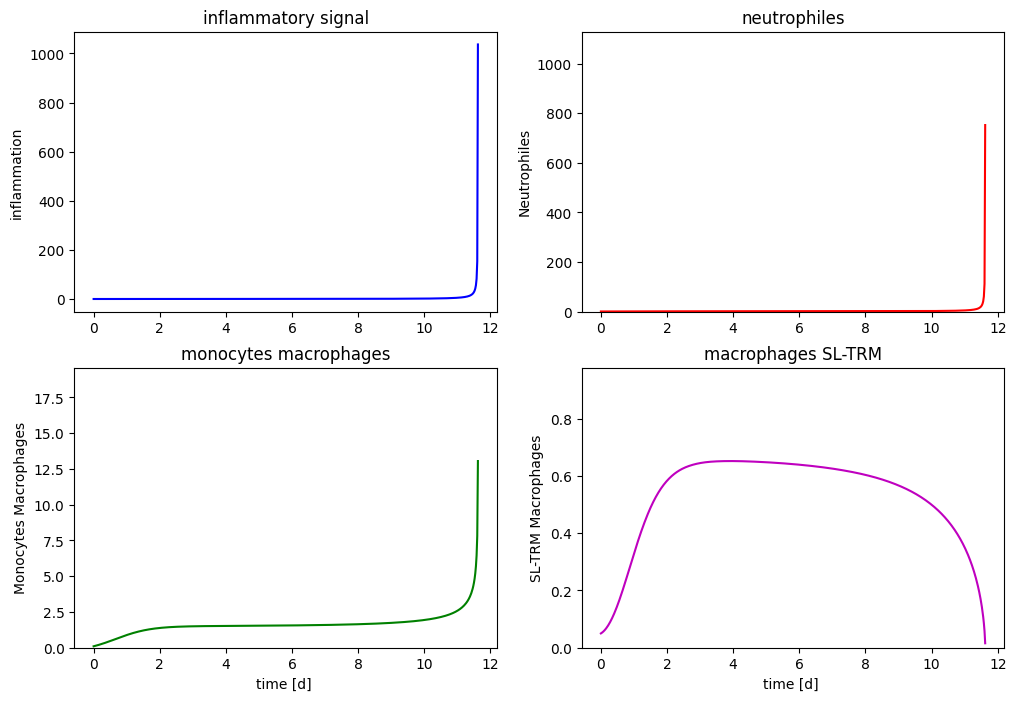

In [67]:
inflam_adim_oliv([0.5, 1, 0.1, 0.05],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.38, b=1, duree=20) 
 

valeurs finales: Signal=1093.395, Neutrophiles=793.325, Momac=13.209, SL-TRM=0.008


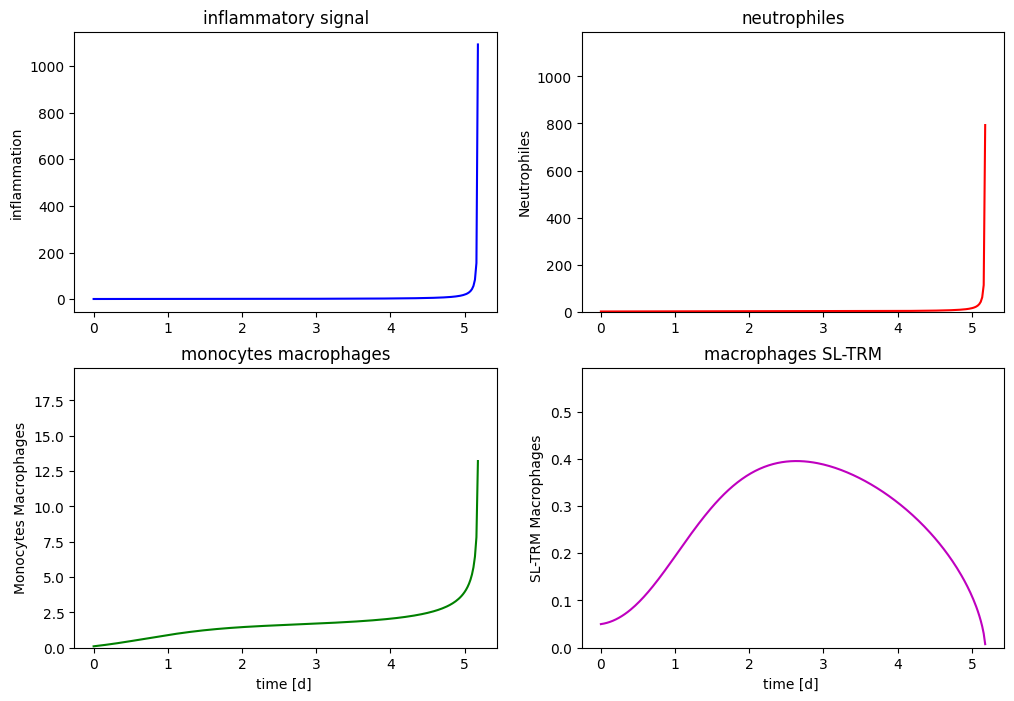

In [68]:
inflam_adim_andrea([0.5, 1, 0.1, 0.05],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,delta_T=0.5, a=0.38, b=1, duree=20) 
 

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


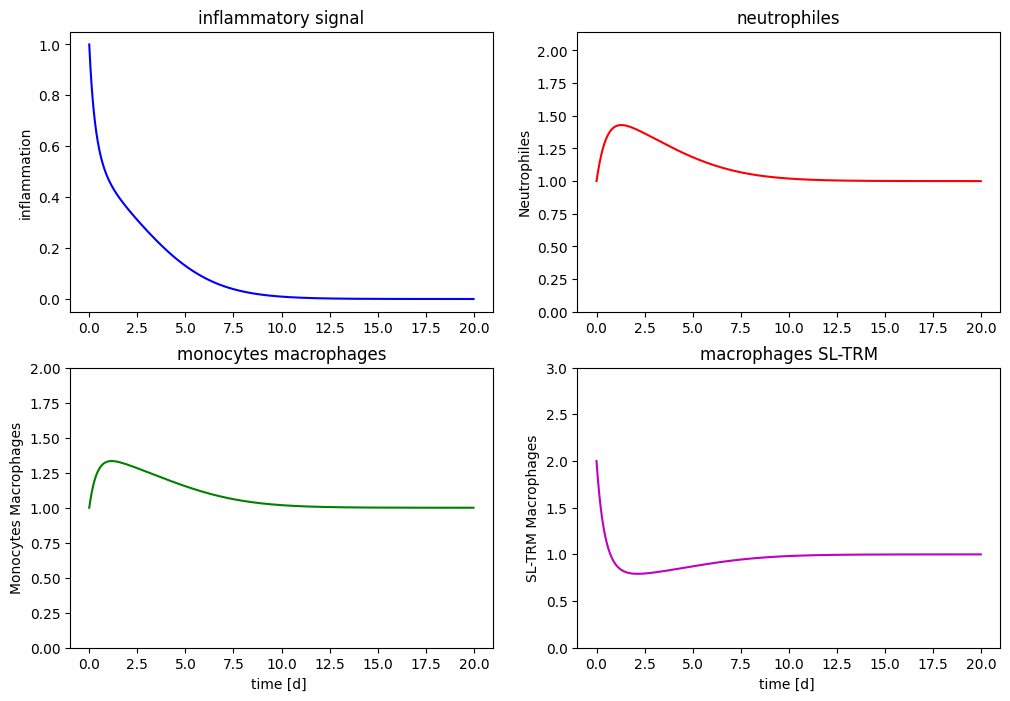

In [69]:
inflam_adim_oliv([1, 1, 1, 2],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.38, b=1, duree=20) 
 

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=0.999


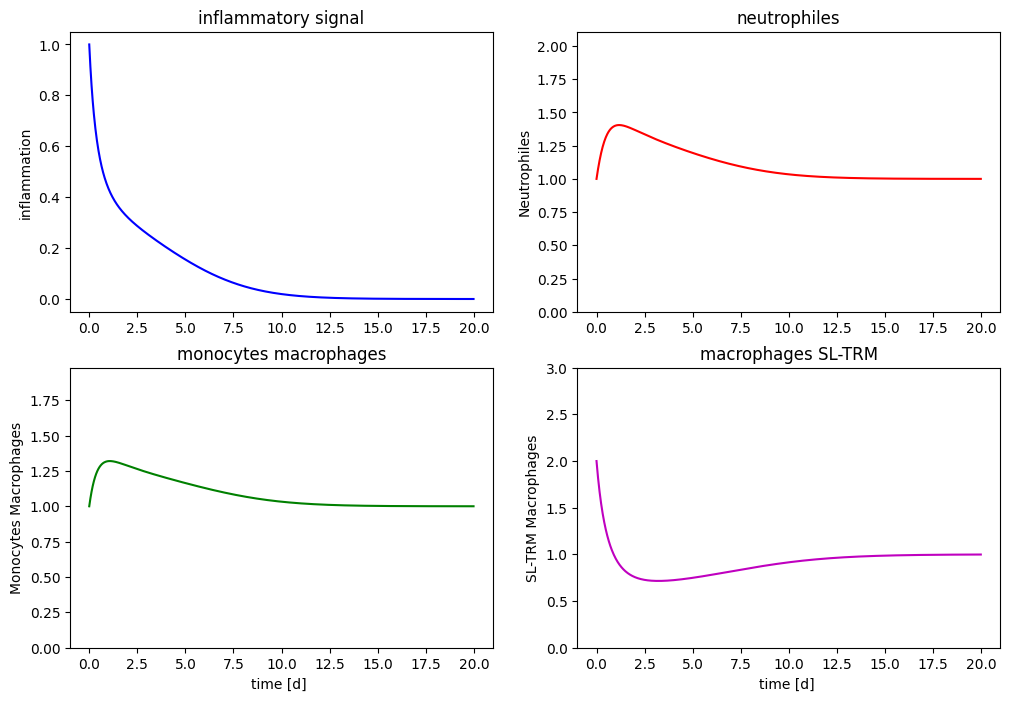

In [70]:
inflam_adim_andrea([1, 1, 1, 2],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,delta_T=0.5, a=0.38, b=1, duree=20)

on remarque que si on augmente la population initiale de macrophages SL-TRM le patient triomphe de l'inflammation

En comparant le modèle oliv avec le modèle andrea ($\delta_T \neq \delta_M$) on voit des comportements analogues. Lorsqu'on baisse (resp. augmente) $\delta_T$ le modèle revient moins (resp. plus) facilement à l'équilibre.

Tracé du ratio pro/anti_inflammatoire = N+M/T
(idee de Gabriel Courties)

In [71]:
def inflam_adim_gab(y0, alpha, beta, gamma, delta_N, delta_M, a, b, duree):

    # Résolution des équations différentielles du modèle de la réponse immunitaire
    # le système est raide, on utilise la méthode BDF
    sol = solve_ivp(system_adim_oliv, [0, duree], y0, 'Radau',t_eval=np.arange(0,duree,duree/1000), dense_output=False,
                    args=(alpha, beta, gamma, delta_N, delta_M, a, b))
    S,N,M,T = sol.y
    t=sol.t
    # Traçage des résultats
    plt.figure(figsize=(12, 8))

    plt.subplot(231)
    plt.plot(t, S, 'b', label='inflammation')
    plt.ylabel('inflammation')
    plt.title('inflammatory signal')

    plt.subplot(232)
    plt.plot(t, N, 'r', label='Neutrophiles')
    plt.ylabel('Neutrophiles')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(N)
    plt.ylim(bottom=0, top=ymax)
    plt.title('neutrophiles')

    plt.subplot(233)
    plt.plot(t,M, 'g')
    plt.xlabel('time [d] ')
    plt.ylabel('Monocytes Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(M)
    plt.ylim(bottom=0, top=ymax)
    plt.title('monocytes macrophages')

    plt.subplot(234)
    plt.plot(t,T, 'm')
    plt.xlabel('time [d] ')
    plt.ylabel('SL-TRM Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(T)
    plt.ylim(bottom=0, top=ymax )
    plt.title('macrophages SL-TRM')

    plt.subplot(235)
    plt.plot(t,(N+M)/T, 'm')
    plt.xlabel('time [d] ')
    plt.ylabel('ratio pro vs anti inflammatory')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max((N+M)/T)
    plt.ylim(bottom=0, top=ymax )
    plt.title('ratio pro vs anti inflammatory')

    plt.subplot(236)
    plt.plot(N+M,T, 'm')
    plt.xlabel('N+M pro-inflammatory')
    plt.ylabel('T anti-inflammatory')
    plt.ticklabel_format(style='plain', axis='y')
    ymin = 0.9 * np.min(T)
    ymax = 1.1 * np.max(T)
    plt.ylim(bottom=ymin, top=ymax )
    plt.title('phase plane immune signal   vs ration pro vs anti inflammatory')

    #plt.subplot(325)
    #plt.plot(M,T, 'm')
    #plt.xlabel('Momac')
    #plt.ylabel('SL-TRM Macrophages')
    #plt.ticklabel_format(style='plain', axis='y')
    #ymax = 1.5 * np.max(T)
    #plt.ylim(bottom=0, top=ymax)
    #plt.figtext(0.3, 0.01, 'Plan de phase entre Momac et SL-TRM ', ha='center', fontsize=12)

    #plt.subplot(326)
    #plt.plot(S,T, 'm')
    #plt.xlabel('signal inflammatoire')
    #plt.ylabel('SL-TRM Macrophages')
    #plt.ticklabel_format(style='plain', axis='y')
    #ymax = 1.5 * np.max(T)
    #plt.ylim(bottom=0, top=ymax)
    #plt.figtext(0.7, 0.01, 'Plan de phase entre inflammation et SL-TRM ', ha='center', fontsize=12)

    print('valeurs finales:',f"Signal={S[-1]:.3f}, Neutrophiles={N[-1]:.3f}, Momac={M[-1]:.3f}, SL-TRM={T[-1]:.3f}")
    plt.show()
    return

valeurs finales: Signal=0.042, Neutrophiles=1.060, Momac=1.055, SL-TRM=0.949


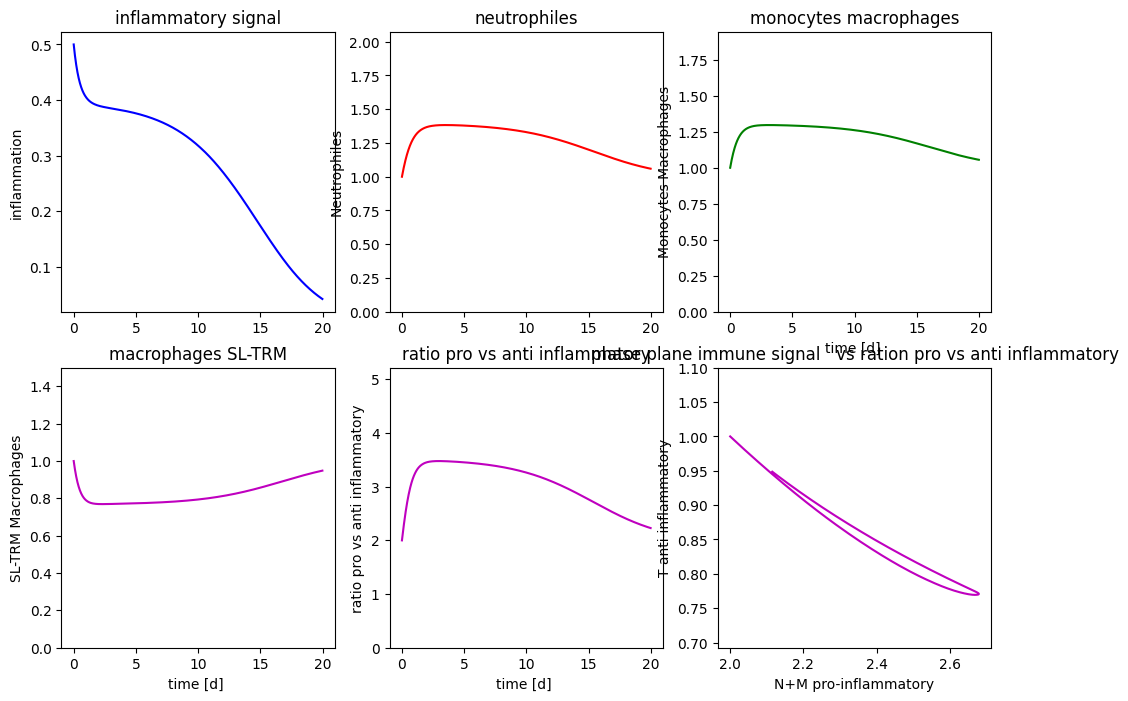

In [72]:
inflam_adim_gab([0.5, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.55, b=1, duree=20)

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


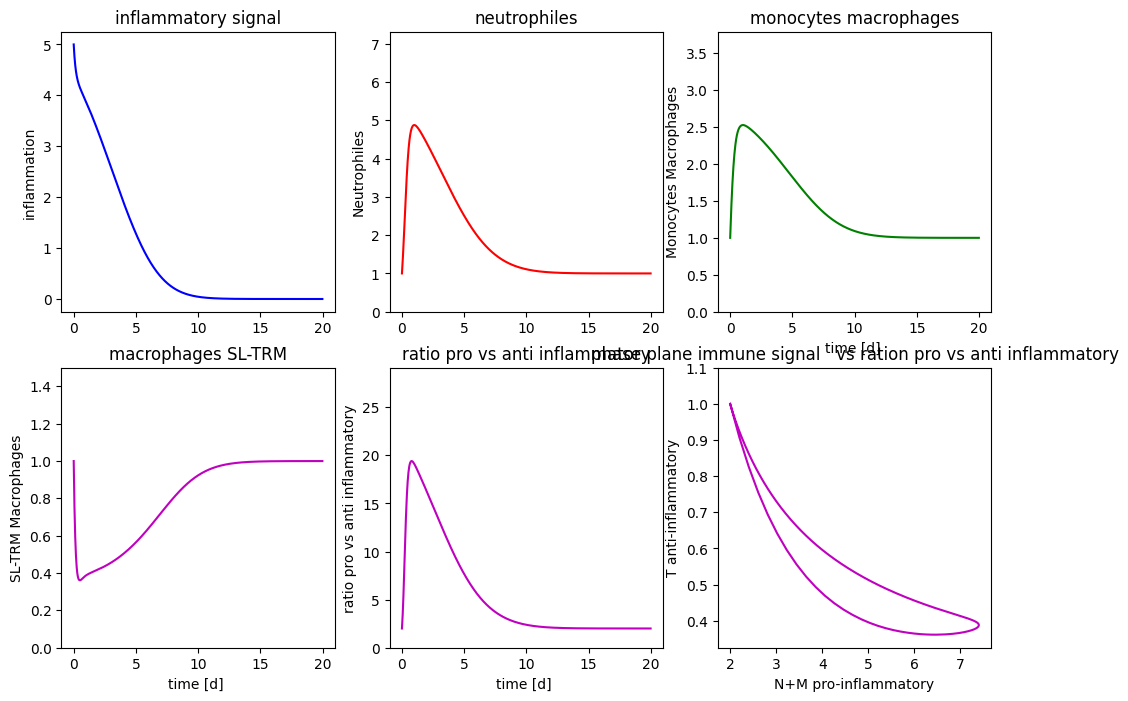

In [73]:
inflam_adim_gab([5, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.05, b=1, duree=20)

### Diagramme de persistence avec dégradation de S
on constate que la stabilité de l'état sain (disease-free) est augmentée.

Calcul de la classification pour chaque point (A, S)...


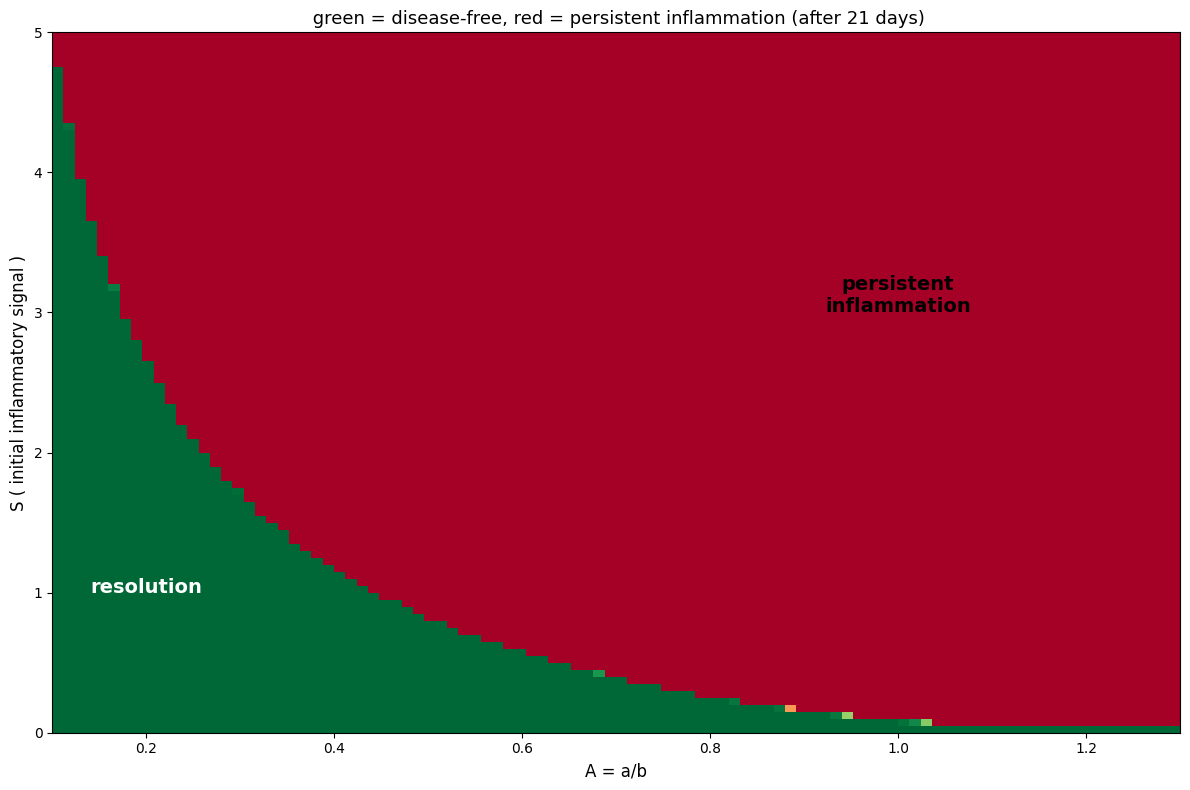

✓ Classification complétée et sauvegardée !


In [74]:
import numpy as np
from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt

def simulate_and_classify(A, S_init, duree=21):
    """
    Simule le système pour une condition initiale (A, S_init) et classifie le résultat.
    Retourne True si disease-free (proche de (0,1,1,1)), False si inflammation persiste.
    """
    # Récupérer les autres variables initiales en fonction de A et S
    alpha, beta, gamma, delta_N, delta_M, b, c = 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.1
    a = A * b
    
    # Pour une condition initiale avec S donnée, on peut prendre N, M, T proches de l'équilibre
    # ou exploiter la dynamique pour une condition initiale simple
    N_init = 1.0
    M_init = 1.0
    T_init = 1.0
    
    y0 = [S_init, N_init, M_init, T_init]
    params = (alpha, beta, gamma, delta_N, delta_M, a, b, c)
    
    # Intégration
    t_span = [0, duree]
    t_eval = np.linspace(0, duree, 500)
    
    try:
        sol = solve_ivp(system_adim_degrad, t_span, y0, args=params, t_eval=t_eval, method='Radau', dense_output=True)
        
        if not sol.success:
            return None
        
        # État final
        S_final, N_final, M_final, T_final = sol.y[:, -1]
        
        # Distance à l'équilibre disease-free (0, 1, 1, 1)
        dist = np.sqrt((S_final - 0)**2 + (N_final - 1)**2 + (M_final - 1)**2 + (T_final - 1)**2)
        
        # Classification
        #return dist <= tol  # True si disease-free, False si inflammation persiste
        return dist
    except Exception as e:
        print(f"Erreur pour A={A}, S={S_init}: {e}")
        return None

# Grille d'exploration dans le plan (A, S)
A_range = np.linspace(0.1, 1.3, 100)
S_range = np.linspace(0.0, 5.0, 100)

# Matrice de résultats
results = np.zeros((len(S_range), len(A_range)))

print("Calcul de la classification pour chaque point (A, S)...")
for i, S in enumerate(S_range):
    for j, A in enumerate(A_range):
        result = simulate_and_classify(A, S, duree=21)
        if result is not None:
            #results[i, j] = 1.0 if result else 0.0  # 1 = disease-free (vert), 0 = inflammation (rose)
            results[i, j] = result  # stocker la distance pour une visualisation plus nuancée
        else:
            results[i, j] = np.nan

# Tracé
fig, ax = plt.subplots(figsize=(12, 8))
tol_val = 0.05
vmax = np.nanmax(results)
plot_results = results.copy().astype(float)

if vmax <= tol_val:
    plot_results[~np.isnan(plot_results)] = 1.0
else:
    mask = ~np.isnan(plot_results)
    plot_results[mask] = np.where(
        plot_results[mask] <= tol_val,
        1.0,
        1.0 - (plot_results[mask] - tol_val) / (vmax - tol_val)
    )
    plot_results[np.isnan(plot_results)] = 0.0
    plot_results = np.clip(plot_results, 0, 1)

results = plot_results
# Colors: green for disease-free, pink/red for persistent inflammation
# Palette grayscale, better for black-and-white printing:
# 0 (persistent inflammation) -> dark, 1 (disease-free) -> light
# Colors: green for disease-free, red for persistent inflammation
cmap = plt.cm.RdYlGn  # Red-Yellow-Green
cmap = plt.cm.RdYlGn  # Red-Yellow-Green
im = ax.imshow(results, extent=[A_range[0], A_range[-1], S_range[0], S_range[-1]], 
               origin='lower', cmap=cmap, aspect='auto', vmin=0, vmax=1)

ax.set_xlabel('A = a/b', fontsize=12)
ax.set_ylabel('S ( initial inflammatory signal )', fontsize=12)
ax.set_title(' green = disease-free, red = persistent inflammation (after 21 days)', fontsize=13)
# Add text annotations
ax.text(1, 3, 'persistent\ninflammation', fontsize=14, color='black', ha='center', weight='bold')
ax.text(0.2, 1.0, 'resolution', fontsize=14, color='white', ha='center', weight='bold')
# Colorbar avec labels explicites
#cbar = fig.colorbar(im, ax=ax)
#cbar.set_label('state after 21 days', rotation=270, labelpad=20)
#cbar.set_ticks([0.25, 0.75])
#cbar.set_ticklabels(['Persisting\ninflammation', 'Disease-free\n(healing)'])

plt.tight_layout()
plt.savefig('phase_plane_classification.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Classification complétée et sauvegardée !")

diagramme de persistence en fonction de la population initiale de ST-TRM

Calcul de la classification pour chaque point (A, T)...


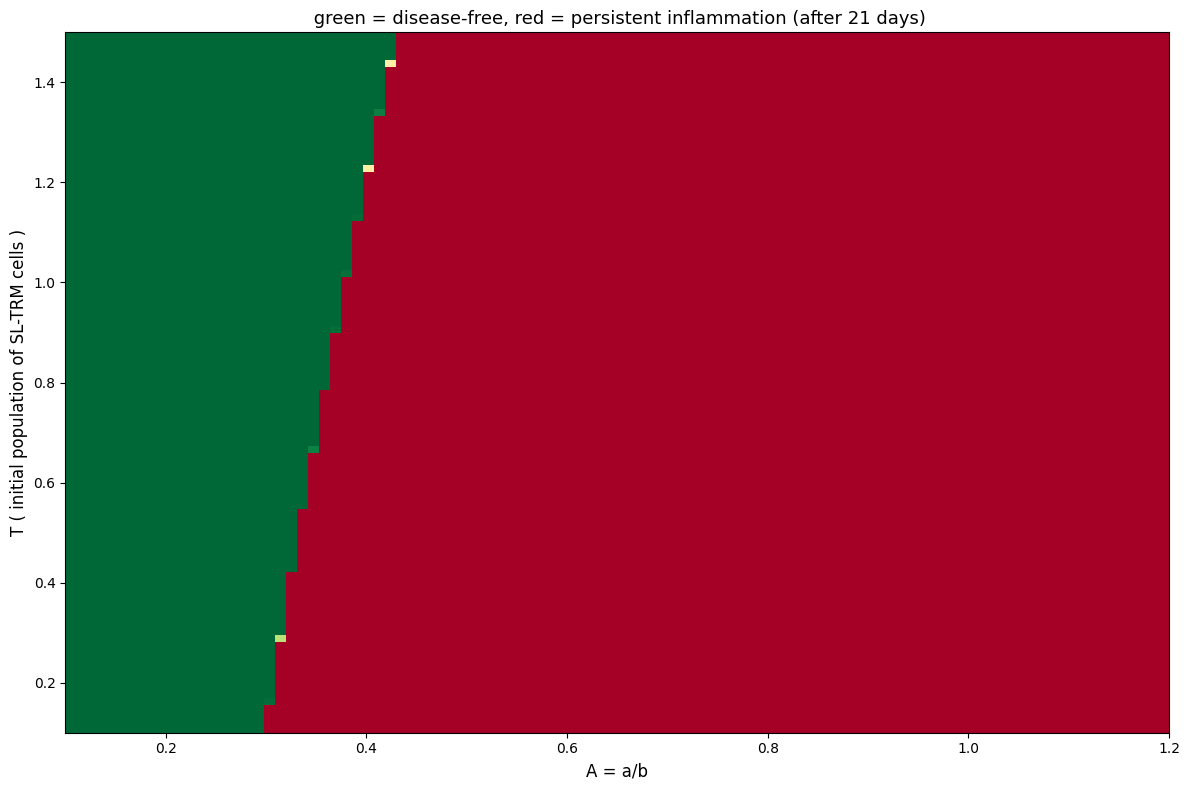

✓ Classification complétée et sauvegardée !


In [75]:
import numpy as np
from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt

def simulate_and_classify_T(A, T_init, duree=21):
    """
    Simule le système pour une condition initiale (A, T_init) et classifie le résultat.
    Retourne True si disease-free (proche de (0,1,1,1)), False si inflammation persiste.
    """
    # Récupérer les autres variables initiales en fonction de A et S
    alpha, beta, gamma, delta_N, delta_M, b = 1.0, 1.0, 1.0, 1.0, 1.0, 1.0
    a = A * b
    
    # Pour une condition initiale avec S donnée, on peut prendre N, M, T proches de l'équilibre
    # ou exploiter la dynamique pour une condition initiale simple
    S_init = 1.0
    N_init = 1.0
    M_init = 1.0
    
    y0 = [S_init, N_init, M_init, T_init]
    params = (alpha, beta, gamma, delta_N, delta_M, a, b)
    
    # Intégration
    t_span = [0, duree]
    t_eval = np.linspace(0, duree, 500)
    
    try:
        sol = solve_ivp(system_adim_oliv, t_span, y0, args=params, t_eval=t_eval, method='Radau', dense_output=True)
        
        if not sol.success:
            return None
        
        # État final
        S_final, N_final, M_final, T_final = sol.y[:, -1]
        
        # Distance à l'équilibre disease-free (0, 1, 1, 1)
        dist = np.sqrt((S_final - 0)**2 + (N_final - 1)**2 + (M_final - 1)**2 + (T_final - 1)**2)
        
        # Classification
        #return dist <= tol  # True si disease-free, False si inflammation persiste
        return dist
    except Exception as e:
        print(f"Erreur pour A={A}, S={S_init}: {e}")
        return None

# Grille d'exploration dans le plan (A, S)
A_range = np.linspace(0.1, 1.2, 100)
T_range = np.linspace(0.1, 1.5, 100)

# Matrice de résultats
results = np.zeros((len(T_range), len(A_range)))

print("Calcul de la classification pour chaque point (A, T)...")
for i, T in enumerate(T_range):
    for j, A in enumerate(A_range):
        result = simulate_and_classify_T(A, T, duree=21)
        if result is not None:
            #results[i, j] = 1.0 if result else 0.0  # 1 = disease-free (vert), 0 = inflammation (rose)
            results[i, j] = result  # stocker la distance pour une visualisation plus nuancée
        else:
            results[i, j] = np.nan

# Tracé
fig, ax = plt.subplots(figsize=(12, 8))
tol_val = 0.05
vmax = np.nanmax(results)
plot_results = results.copy().astype(float)

if vmax <= tol_val:
    plot_results[~np.isnan(plot_results)] = 1.0
else:
    mask = ~np.isnan(plot_results)
    plot_results[mask] = np.where(
        plot_results[mask] <= tol_val,
        1.0,
        1.0 - (plot_results[mask] - tol_val) / (vmax - tol_val)
    )
    plot_results[np.isnan(plot_results)] = 0.0
    plot_results = np.clip(plot_results, 0, 1)

results = plot_results
# Colors: green for disease-free, pink/red for persistent inflammation
cmap = plt.cm.RdYlGn  # Red-Yellow-Green
im = ax.imshow(results, extent=[A_range[0], A_range[-1], T_range[0], T_range[-1]], 
               origin='lower', cmap=cmap, aspect='auto', vmin=0, vmax=1)

ax.set_xlabel('A = a/b', fontsize=12)
ax.set_ylabel('T ( initial population of SL-TRM cells )', fontsize=12)
ax.set_title(' green = disease-free, red = persistent inflammation (after 21 days)', fontsize=13)

# Colorbar avec labels explicites
#cbar = fig.colorbar(im, ax=ax)
#cbar.set_label('state after 21 days', rotation=270, labelpad=20)
#cbar.set_ticks([0.25, 0.75])
#cbar.set_ticklabels(['Persisting\ninflammation', 'Disease-free\n(healing)'])

plt.tight_layout()
plt.savefig('phase_plane_classification.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Classification complétée et sauvegardée !")
